In [1]:
# =============================================================================
# Saben la propietat commutativa? a x b vs b x a  (A998, Espanya, curs 2025-26)
# =============================================================================
# PREGUNTA: els alumnes tracten a x b i b x a com el mateix fet? I si no, els va
# millor quan el factor GRAN va primer o quan va segon?
#
import re
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

MIN_ATTEMPTS_PER_DIRECTION = 1

EXCLUDE_FAST_WRONG_STUDENTS = True
FAST_WRONG_MAX_RT = 1.5           # segons
REPORT_FAST_WRONG_IMPACT = True   # una query extra (sense filtrar) per veure que es perd
YEARS = ["ES_2025"]
# =============================================================================

HERE = Path.cwd()          # descriptive/ or mechanistic/ (run the notebook from its own folder)
ROOT = HERE
while not (ROOT / "databricks_connector.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("databricks_connector.py not found in any parent directory")
    ROOT = ROOT.parent      # repo root -- holds databricks_connector.py and cached_query.py
sys.path.insert(0, str(ROOT))
from cached_query import cached_query
(HERE / "cache").mkdir(exist_ok=True)
(HERE / "plots").mkdir(exist_ok=True)

SQL_PATH = HERE / "queries" / "a998_commutativity_paired_by_age.sql"
CACHE_DIR = HERE / "cache"

# El .sql porta el default (>= 1) escrit als dos HAVING marcats amb
# "-- {MIN_ATTEMPTS}", aixi que el fitxer segueix sent executable sol. Aqui es
# reescriuen tots dos segons MIN_ATTEMPTS_PER_DIRECTION. Si els marcadors
# desapareguessin del .sql, aixo peta -- millor petar que executar silenciosament
# un llindar diferent del que diu el notebook.
sql_raw = SQL_PATH.read_text(encoding="utf-8")
sql_text, n_subs = re.subn(r">= \d+(\s*-- \{MIN_ATTEMPTS\})",
                            f">= {MIN_ATTEMPTS_PER_DIRECTION}\\1", sql_raw)
assert n_subs == 2, (f"Esperava 2 marcadors -- {{MIN_ATTEMPTS}} al .sql, n'he trobat {n_subs}. "
                     "Han canviat els HAVING de a998_commutativity_paired_by_age.sql?")

years_sql = ", ".join(f"'{y}'" for y in YEARS)
sql_text, n_y = re.subn(r"IN \([^)]*\)(\s*-- \{YEARS\})",
                         f"IN ({years_sql})\\1", sql_text)
assert n_y == 1, (f"Esperava 1 marcador -- {{YEARS}} al .sql, n'he trobat {n_y}. "
                  "Ha canviat el filtre academic_year_id?")

# --- filtre de respostes rapides i erronies: els dos marcadors nous ---------
# Un sol lloc per als tres .sql: aquesta, la de perfils del test de permutacio i
# la de simetria del coneixement, que el tornen a cridar a la seva cel.la.
# Si un marcador es mou, aixo peta en lloc de consultar en silenci una altra
# poblacio -- mateix criteri que -- {YEARS} i -- {MIN_ATTEMPTS}.
def apply_fast_wrong(sql_in, exclude=None, label=""):
    exclude = EXCLUDE_FAST_WRONG_STUDENTS if exclude is None else exclude
    out, n_rt = re.subn(r"< [\d.]+(\s*-- \{FAST_WRONG_RT\})",
                        f"< {FAST_WRONG_MAX_RT}\\1", sql_in)
    assert n_rt == 1, f"{label}: esperava 1 marcador -- {{FAST_WRONG_RT}}, n'he trobat {n_rt}"
    clause = "has_fast_wrong = 0" if exclude else "1 = 1"
    out, n_f = re.subn(r"(?:has_fast_wrong = 0|1 = 1)(\s*-- \{FAST_WRONG_FILTER\})",
                       clause + "\\1", out)
    assert n_f == 1, f"{label}: esperava 1 marcador -- {{FAST_WRONG_FILTER}}, n'he trobat {n_f}"
    return out


# sql_text_unfiltered = nomes YEARS + MIN_ATTEMPTS; serveix per a la comparacio
# de mes avall (la mateixa query amb el filtre apagat).
sql_text_unfiltered = sql_text
sql_text = apply_fast_wrong(sql_text_unfiltered, label=SQL_PATH.name)

com = cached_query(SQL_PATH, CACHE_DIR, sql_text=sql_text)

print("A998 | commutativitat aparellada intra-alumne")
print(f"YEARS = {YEARS} | MIN_ATTEMPTS_PER_DIRECTION = {MIN_ATTEMPTS_PER_DIRECTION}")
print("Direccio: 'gran primer' = factor gran escrit primer (8x7) | 'gran segon' = (7x8)")
print(f"Files: {len(com):,} (any x parella lo<hi x edat) | cache -> {CACHE_DIR.relative_to(ROOT)}/")
print(f"Parelles: {com.groupby(['lo','hi']).ngroups} | edats: {sorted(com['classroom_course_age'].unique())}")
assert com["academic_year_id"].nunique() == len(YEARS), "La query ha tornat anys que no son a YEARS"
print(f"Columnes de repartiment: {[c for c in com.columns if c.startswith('pct_')]}")
print(f"Filtre resposta rapida i erronia: "
      f"{'ACTIU' if EXCLUDE_FAST_WRONG_STUDENTS else 'DESACTIVAT'}"
      f" -- incorrecta en < {FAST_WRONG_MAX_RT} s => fora l'alumne sencer (dins de l'any)")

# --- que es perd amb el filtre? --------------------------------------------
# La MATEIXA query amb i sense filtre. ATENCIO amb el que es compta: n_students
# es per (parella, edat), aixi que la suma per edat compta cada alumne un cop
# per parella -- son OBSERVACIONS APARELLADES (alumne x parella), no alumnes.
# Com a ratio abans/despres serveix; com a recompte d'alumnes, no.
if EXCLUDE_FAST_WRONG_STUDENTS and REPORT_FAST_WRONG_IMPACT:
    com_all = cached_query(SQL_PATH, CACHE_DIR,
                           sql_text=apply_fast_wrong(sql_text_unfiltered, exclude=False,
                                                     label=SQL_PATH.name))
    obs_all = com_all.groupby("classroom_course_age")["n_students"].sum()
    obs_kept = com.groupby("classroom_course_age")["n_students"].sum()
    # reindex: si el filtre buida una edat sencera, ha de sortir 0, no desapareixer
    impact = pd.DataFrame({"obs_sense_filtre": obs_all,
                           "obs_amb_filtre": obs_kept.reindex(obs_all.index).fillna(0)})
    impact["pct_perdut"] = 100 * (1 - impact["obs_amb_filtre"] / impact["obs_sense_filtre"])
    print("\nObservacions aparellades (alumne x parella) per edat, sense i amb filtre:")
    print(impact.round(1).to_string())
    print("Si pct_perdut es mou molt amb l'edat, les corbes per edat de sota barregen")
    print("aprenentatge amb composicio de la mostra: cal dir-ho en ensenyar-les.")

A998 | commutativitat aparellada intra-alumne
YEARS = ['ES_2025'] | MIN_ATTEMPTS_PER_DIRECTION = 1
Direccio: 'gran primer' = factor gran escrit primer (8x7) | 'gran segon' = (7x8)
Files: 350 (any x parella lo<hi x edat) | cache -> descriptive\cache/
Parelles: 45 | edats: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
Columnes de repartiment: ['pct_both_right', 'pct_only_big_first', 'pct_only_big_second', 'pct_neither_right']
Filtre resposta rapida i erronia: ACTIU -- incorrecta en < 1.5 s => fora l'alumne sencer (dins de l'any)

Observacions aparellades (alumne x parella) per edat, sense i amb filtre:
                      obs_sense_filtre  obs_amb_filtre  pct_perdut
classroom_course_age                                              
8                               140175           42791        69.5
9                               183921           90853        50.6
10                               95018           48541     

In [2]:
# --- factibilitat: hi ha prou alumnes aparellats per casella? --------------
# Comprovacio previa (abans de creure's cap numero): quants alumnes aporten una
# observacio aparellada a cada (parella, edat).
MIN_STUDENTS = 100

print("Alumnes aparellats per casella (any x parella x edat):")
print(com["n_students"].describe().round(1))

thin = com[com["n_students"] < MIN_STUDENTS]
print(f"\n{len(thin)} / {len(com)} caselles amb < {MIN_STUDENTS} alumnes aparellats -- s'exclouen.")
print("Concentrades a (any x edat):")
print(thin.groupby(["academic_year_id", "classroom_course_age"]).size().to_string())

print("\nIntents per alumne i casella (mitjana):")
print(com["n_attempts_per_student_avg"].describe().round(2))
print("~2.2 => la gran majoria d'alumnes tenen NOMES 1 intent per direccio.")

Alumnes aparellats per casella (any x parella x edat):
count     350.0
mean     1032.4
std       878.8
min         1.0
25%       503.5
50%       926.0
75%      1208.2
max      7514.0
Name: n_students, dtype: float64

14 / 350 caselles amb < 100 alumnes aparellats -- s'exclouen.
Concentrades a (any x edat):
academic_year_id  classroom_course_age
ES_2025           8                       7
                  9                       7

Intents per alumne i casella (mitjana):
count    350.00
mean       2.27
std        0.11
min        2.00
25%        2.22
50%        2.28
75%        2.32
max        2.86
Name: n_attempts_per_student_avg, dtype: float64
~2.2 => la gran majoria d'alumnes tenen NOMES 1 intent per direccio.


In [3]:
# --- resum per edat: les mitjanes i el repartiment d'alumnes --------------
com = com.copy()
valid = com[com["n_students"] >= MIN_STUDENTS].copy()

PCT_COLS = ["pct_both_right", "pct_only_big_first", "pct_only_big_second",
            "pct_neither_right"]

# Tot ponderat per alumnes: dins d'una edat, una parella amb 25k alumnes
# aparellats no pot pesar igual que una amb 200.
def wavg(g, col):
    return np.average(g[col], weights=g["n_students"])

summary = (valid.groupby("classroom_course_age")
                .apply(lambda g: pd.Series({
                    "n_parelles": len(g),
                    "alumnes": g["n_students"].sum(),
                    "acc_gran_primer": wavg(g, "acc_big_first"),
                    "acc_gran_segon": wavg(g, "acc_big_second"),
                    "mean_diff": wavg(g, "mean_diff"),
                    "mean_abs_diff": wavg(g, "mean_abs_diff"),
                    **{c: wavg(g, c) for c in PCT_COLS},
                }), include_groups=False))

print(f"Resum per edat ({', '.join(YEARS)}, ponderat per alumnes):")
print(summary[["n_parelles", "alumnes", "acc_gran_primer", "acc_gran_segon",
               "mean_diff", "mean_abs_diff"]].round(4).to_string())

# Els quatre grups han de sumar 100 per construccio; si no, la query no reparteix
# els alumnes com diu que els reparteix i el panell de percentatges no vol dir res.
assert np.allclose(summary[PCT_COLS].sum(axis=1), 100, atol=0.05), \
    "Els quatre grups no sumen 100 -- revisa la particio de la query"

pcts = summary[PCT_COLS].copy()
pcts["desacord_only+only"] = (summary["pct_only_big_first"]
                              + summary["pct_only_big_second"])
print("\n% d'alumnes aparellats per cas (suma 100 per construccio):")
print(pcts.round(2).to_string())

a_lo, a_hi = summary.index.min(), summary.index.max()
r_lo, r_hi = summary.loc[a_lo], summary.loc[a_hi]

print("\n>>> LECTURA PRINCIPAL")
print("mean_diff es un ordre de magnitud mes petit que mean_abs_diff a TOTES les")
print(f"edats (a edat {a_lo}: {r_lo['mean_diff']:+.4f} vs {r_lo['mean_abs_diff']:.4f}), i el signe es")
print("sempre lleugerament negatiu: hi ha, com a molt, un biaix de direccio")
print("minuscul i a favor del factor GRAN SEGON (7x8 una mica millor que 8x7),")
print("mentre que el desacord intra-alumne es molt mes gran. Aixo es l'efecte que")
print("et preocupava: una resta de marginals hauria donat ~0 i s'hauria llegit com")
print("'ja se saben la commutativa', quan de fet els alumnes SI responen les dues")
print("direccions diferent -- nomes que uns cap a un costat i uns cap a l'altre,")
print("cancel.lant-se en agregat.")
print(f"\nmean_abs_diff baixa de {r_lo['mean_abs_diff']:.3f} (edat {a_lo}) a "
      f"{r_hi['mean_abs_diff']:.3f} (edat {a_hi}) => el desacord")
print("es redueix amb l'edat, pero no arriba a zero.")

print("\n>>> EL MATEIX EN ALUMNES (el que es dibuixa al panell 3 de la tendencia)")
print(f"Edat {a_lo}: {r_lo['pct_both_right']:.1f}% encerten les dues direccions, "
      f"{r_lo['pct_only_big_first'] + r_lo['pct_only_big_second']:.1f}% nomes una")
print(f"         ({r_lo['pct_only_big_first']:.1f}% nomes gran primer + "
      f"{r_lo['pct_only_big_second']:.1f}% nomes gran segon), "
      f"{r_lo['pct_neither_right']:.1f}% cap.")
print(f"Edat {a_hi}: {r_hi['pct_both_right']:.1f}% les dues, "
      f"{r_hi['pct_only_big_first'] + r_hi['pct_only_big_second']:.1f}% nomes una "
      f"({r_hi['pct_only_big_first']:.1f}% + {r_hi['pct_only_big_second']:.1f}%), "
      f"{r_hi['pct_neither_right']:.1f}% cap.")
print("Les dues corbes 'nomes una direccio' son gairebe simetriques a cada edat:")
print("es la mateixa cancel.lacio de signes, ara comptada en alumnes.")


Resum per edat (ES_2025, ponderat per alumnes):
                      n_parelles  alumnes  acc_gran_primer  acc_gran_segon  mean_diff  mean_abs_diff
classroom_course_age                                                                                
8                           28.0  42783.0           0.8234          0.8467    -0.0233         0.1941
9                           38.0  90199.0           0.8894          0.8859     0.0035         0.1415
10                          45.0  48541.0           0.9115          0.9130    -0.0016         0.1221
11                          45.0  66552.0           0.9230          0.9266    -0.0036         0.1069
12                          45.0  38568.0           0.9219          0.9299    -0.0080         0.1094
13                          45.0  44467.0           0.9308          0.9375    -0.0067         0.0952
14                          45.0  23392.0           0.9339          0.9408    -0.0069         0.0912
15                          45.0   6175.0  

In [4]:
# --- CAVEAT IMPORTANT: mean_abs_diff no es pot llegir en cru --------------
p_hat = (valid["acc_big_first"] + valid["acc_big_second"]) / 2
naive_baseline = 2 * p_hat * (1 - p_hat)
print("Referencia ingenua 2p(1-p) vs |diff| observada (NOMES il·lustratiu):")
chk = pd.DataFrame({
    "mean_abs_diff": valid.groupby(valid["classroom_course_age"])["mean_abs_diff"].mean(),
    "naive_2p(1-p)": naive_baseline.groupby(valid["classroom_course_age"]).mean(),
})
chk["diferencia"] = chk["mean_abs_diff"] - chk["naive_2p(1-p)"]
print(chk.round(4).to_string())
print("\nLa columna 'diferencia' surt negativa a totes les edats. NO vol dir")
print("'mes consistents que l'atzar': vol dir que la referencia esta inflada")
print("per l'heterogeneitat entre alumnes. Per separar soroll de desconeixement")
print("real cal un NULL INTRA-ALUMNE (mateix alumne als dos costats de la")
print("comparacio) -- p.ex. contrastar el desacord entre les dues direccions")
print("de la MATEIXA parella amb el desacord entre DUES PARELLES DIFERENTS de")
print("dificultat semblant, pel mateix alumne. Aixo requereix una query nova i")
print("queda com a seguent pas, no resolt aqui.")

Referencia ingenua 2p(1-p) vs |diff| observada (NOMES il·lustratiu):
                      mean_abs_diff  naive_2p(1-p)  diferencia
classroom_course_age                                          
8                            0.1993         0.2921     -0.0928
9                            0.1241         0.1722     -0.0481
10                           0.1240         0.1575     -0.0334
11                           0.1086         0.1368     -0.0282
12                           0.1111         0.1347     -0.0237
13                           0.0966         0.1202     -0.0236
14                           0.0925         0.1139     -0.0215
15                           0.0757         0.0949     -0.0192

La columna 'diferencia' surt negativa a totes les edats. NO vol dir
'mes consistents que l'atzar': vol dir que la referencia esta inflada
per l'heterogeneitat entre alumnes. Per separar soroll de desconeixement
real cal un NULL INTRA-ALUMNE (mateix alumne als dos costats de la
comparacio) -- p.ex. c

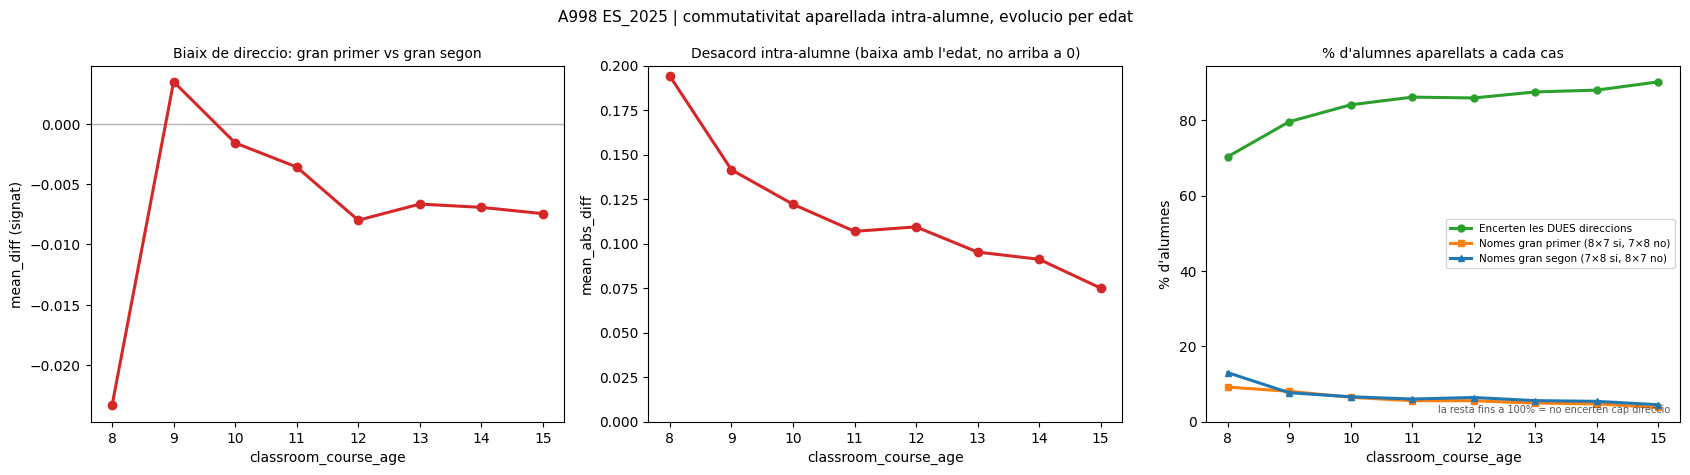

Plot -> descriptive\plots\a998_commutativity_by_age_trend.png


In [5]:
# --- evolucio amb l'edat: biaix, desacord i repartiment d'alumnes ---------
# La pregunta de fons ("quan comencen a saber-se-la") es llegeix com a tendencia.
# Una sola linia per panell: nomes ES_2025 (ES_2024 fora des de 2026-07-30).
#
# PANELL 3 (nou): els MATEIXOS alumnes aparellats dels panells 1 i 2, comptats
# en lloc de promitjats. Es el que fa tangible el que diu mean_abs_diff -- el
# gruix del "no els va igual en les dues direccions" son les dues corbes "nomes
# una direccio", que van gairebe juntes; per aixo la resta de marginals (i el
# mean_diff del panell 1) surt ~0 tot i que hi ha molts alumnes inconsistents.
# La resta fins a 100% son els alumnes que no encerten cap de les dues
# direccions (pct_neither_right, fora del grafic a peticio; surt a la taula).
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

ages = summary.index.to_numpy()

axes[0].axhline(0, color="0.7", lw=1)
axes[0].plot(ages, summary["mean_diff"], "o-", lw=2.2, color="tab:red")
axes[0].set_title("Biaix de direccio: gran primer vs gran segon", fontsize=10)
axes[0].set_ylabel("mean_diff (signat)")

axes[1].plot(ages, summary["mean_abs_diff"], "o-", lw=2.2, color="tab:red")
axes[1].set_ylim(bottom=0)
axes[1].set_title("Desacord intra-alumne (baixa amb l'edat, no arriba a 0)", fontsize=10)
axes[1].set_ylabel("mean_abs_diff")

PCT_STYLE = [
    ("pct_both_right",      "Encerten les DUES direccions",        "tab:green",  "o-"),
    ("pct_only_big_first",  "Nomes gran primer (8\u00d77 si, 7\u00d78 no)", "tab:orange", "s-"),
    ("pct_only_big_second", "Nomes gran segon (7\u00d78 si, 8\u00d77 no)",  "tab:blue",   "^-"),
]
for col, label, color, style in PCT_STYLE:
    axes[2].plot(ages, summary[col], style, lw=2.2, ms=5, color=color, label=label)
axes[2].set_ylim(bottom=0)
axes[2].set_title("% d'alumnes aparellats a cada cas", fontsize=10)
axes[2].set_ylabel("% d'alumnes")
axes[2].legend(fontsize=7.5, loc="center right")
axes[2].text(0.98, 0.02,
             "la resta fins a 100% = no encerten cap direccio",
             transform=axes[2].transAxes, ha="right", va="bottom",
             fontsize=7, color="0.35")

for ax in axes:
    ax.set_xlabel("classroom_course_age")
    ax.set_xticks(range(8, 16))

fig.suptitle(f"A998 {'+'.join(YEARS)} | commutativitat aparellada intra-alumne, "
             f"evolucio per edat", fontsize=11)
fig.tight_layout()
out_path = HERE / "plots" / "a998_commutativity_by_age_trend.png"
fig.savefig(out_path, dpi=130)
plt.show()
print(f"Plot -> {out_path.relative_to(ROOT)}")


28 / 45 pairs clear MIN_STUDENTS = 100 at all 8 ages; the rest are dropped from the ranking (missing at least one age).

Hardest pairs by mean % of pupils that get BOTH directions right (unweighted over ages, lowest first):
       n_ages  both_right  n_min  n_max
lo hi                                  
6  8        8        64.7    120   2829
7  8        8        66.4    155   2868
4  8        8        66.6    122   2926
6  9        8        70.8    133   2963
4  7        8        73.2    149   2946
7  9        8        73.6    144   2919
6  7        8        73.9    126   2960
8  9        8        74.8    130   3004
4  9        8        75.1    126   2921
3  8        8        76.1    130   2972

Drawing 6 figures: 8×6/6×8, 8×7/7×8, 8×4/4×8, 9×6/6×9, 7×4/4×7, 9×7/7×9

=== pair 8×6 / 6×8 | 8 ages | 120-2,829 paired pupils per age


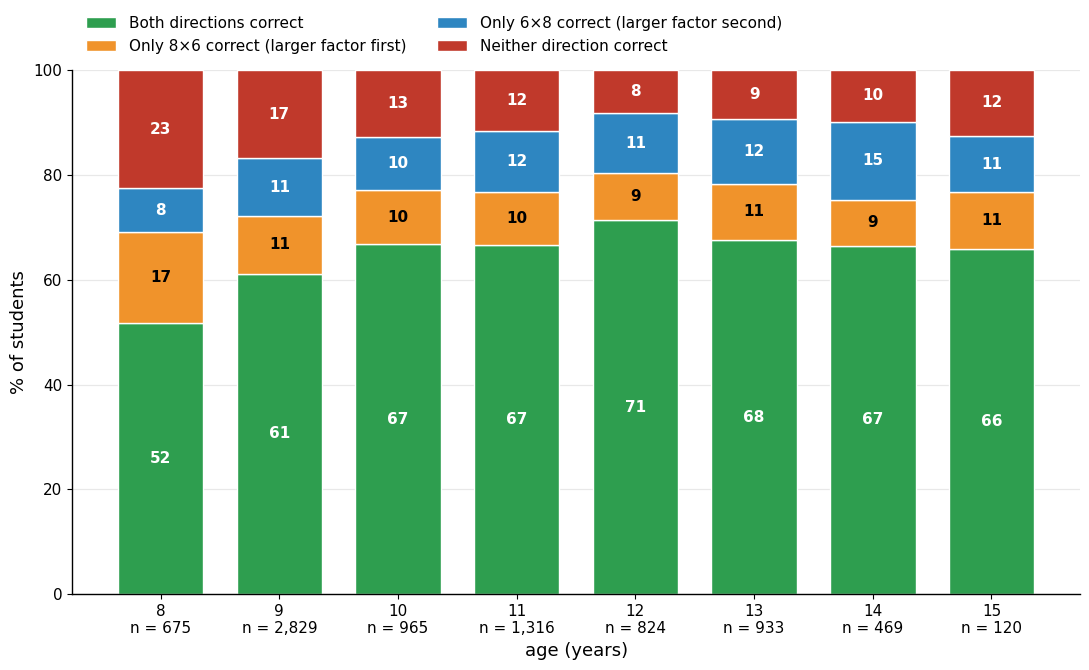

Plot -> descriptive\plots\a998_commutativity_pupil_shares_by_age_en_6x8.png (+ .pdf)
                      pupils  pct_both_right  pct_only_big_first  pct_only_big_second  pct_neither_right
classroom_course_age                                                                                    
8                        675           51.85               17.18                 8.44              22.52
9                       2829           61.19               11.03                10.92              16.86
10                       965           66.84               10.26                10.15              12.75
11                      1316           66.64               10.03                11.63              11.70
12                       824           71.36                8.98                11.41               8.25
13                       933           67.63               10.72                12.33               9.32
14                       469           66.53                8.74           

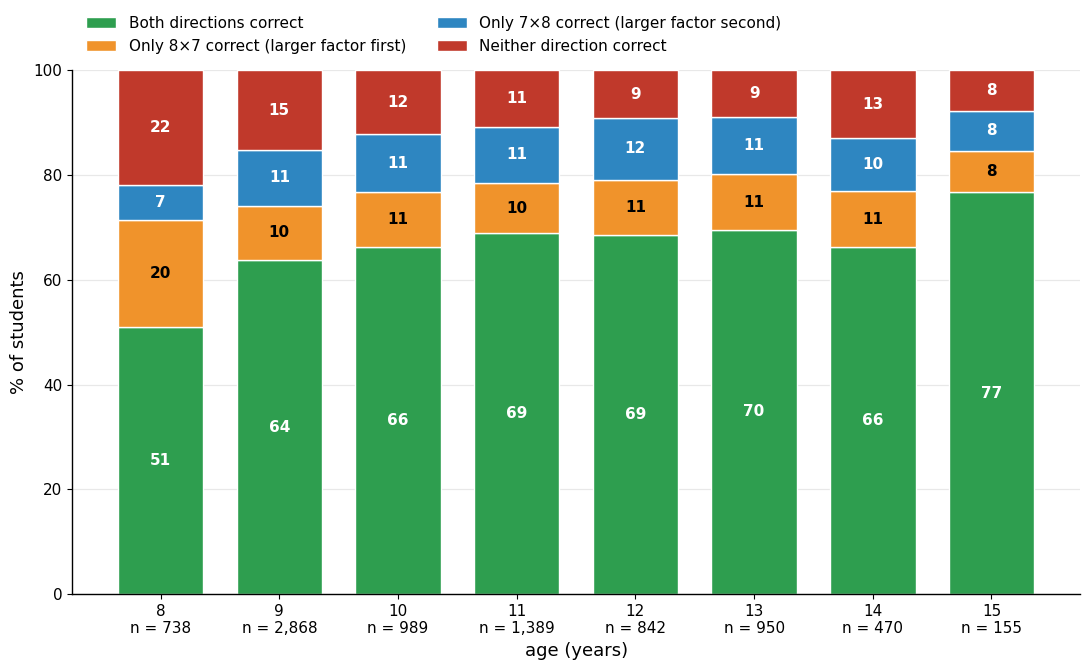

Plot -> descriptive\plots\a998_commutativity_pupil_shares_by_age_en_7x8.png (+ .pdf)
                      pupils  pct_both_right  pct_only_big_first  pct_only_big_second  pct_neither_right
classroom_course_age                                                                                    
8                        738           51.08               20.32                 6.64              21.95
9                       2868           63.77               10.39                10.53              15.31
10                       989           66.23               10.52                11.02              12.24
11                      1389           68.90                9.57                10.73              10.80
12                       842           68.53               10.57                11.76               9.14
13                       950           69.58               10.53                10.95               8.95
14                       470           66.17               10.85           

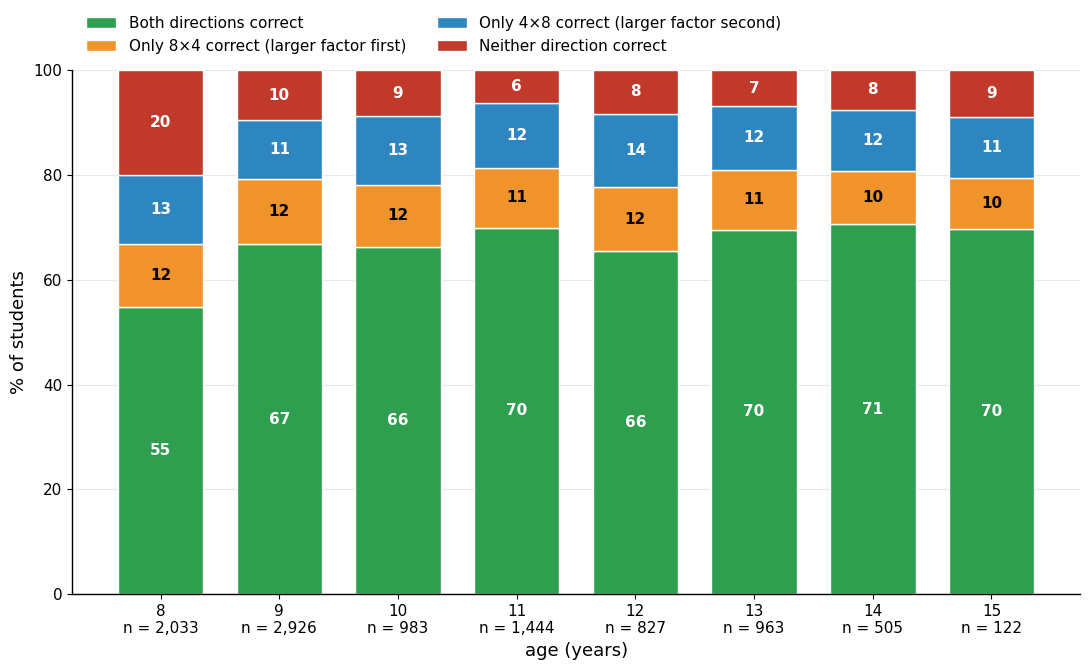

Plot -> descriptive\plots\a998_commutativity_pupil_shares_by_age_en_4x8.png (+ .pdf)
                      pupils  pct_both_right  pct_only_big_first  pct_only_big_second  pct_neither_right
classroom_course_age                                                                                    
8                       2033           54.80               12.05                13.23              19.92
9                       2926           66.75               12.47                11.21               9.57
10                       983           66.23               11.90                13.12               8.75
11                      1444           69.94               11.43                12.33               6.30
12                       827           65.54               12.09                14.03               8.34
13                       963           69.57               11.42                12.15               6.85
14                       505           70.69               10.10           

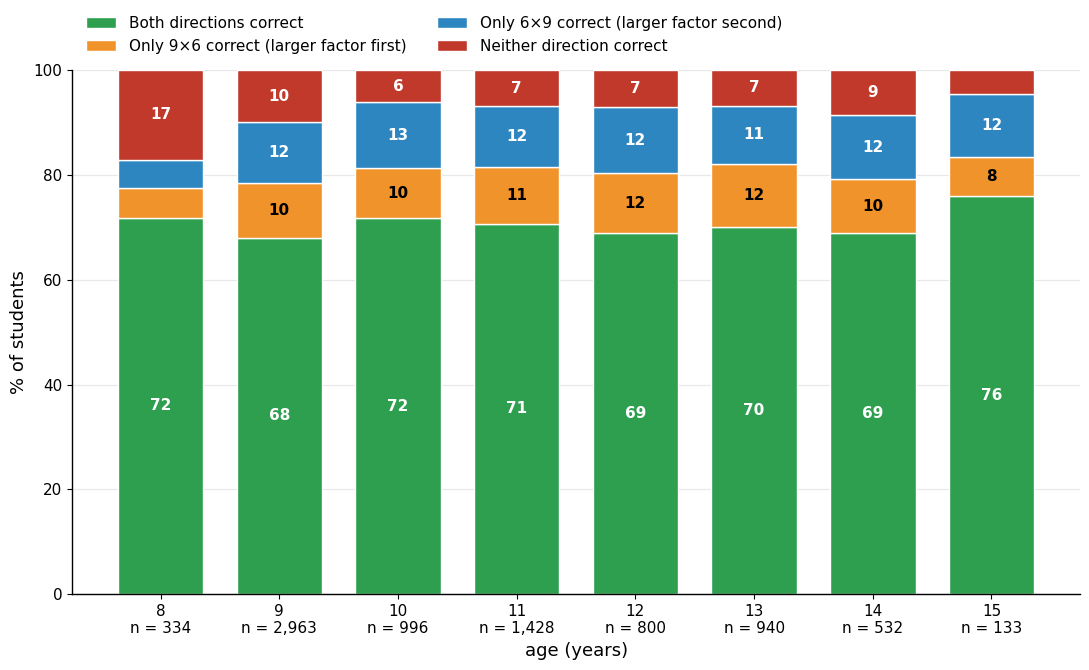

Plot -> descriptive\plots\a998_commutativity_pupil_shares_by_age_en_6x9.png (+ .pdf)
                      pupils  pct_both_right  pct_only_big_first  pct_only_big_second  pct_neither_right
classroom_course_age                                                                                    
8                        334           71.86                5.69                 5.39              17.07
9                       2963           68.04               10.36                11.61               9.99
10                       996           71.79                9.54                12.55               6.12
11                      1428           70.73               10.78                11.62               6.86
12                       800           68.88               11.50                12.50               7.12
13                       940           70.11               12.02                11.06               6.81
14                       532           68.98               10.15           

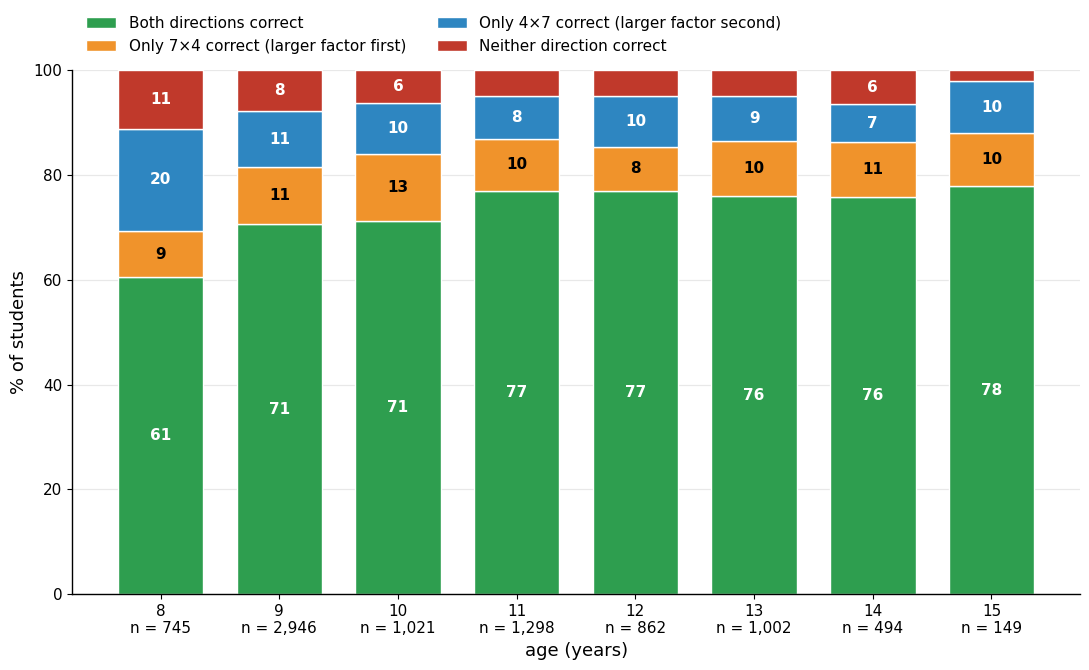

Plot -> descriptive\plots\a998_commutativity_pupil_shares_by_age_en_4x7.png (+ .pdf)
                      pupils  pct_both_right  pct_only_big_first  pct_only_big_second  pct_neither_right
classroom_course_age                                                                                    
8                        745           60.54                8.72                19.60              11.14
9                       2946           70.67               10.79                10.76               7.77
10                      1021           71.30               12.73                 9.70               6.27
11                      1298           76.96                9.94                 8.24               4.85
12                       862           76.91                8.47                 9.63               4.99
13                      1002           76.05               10.38                 8.68               4.89
14                       494           75.71               10.53           

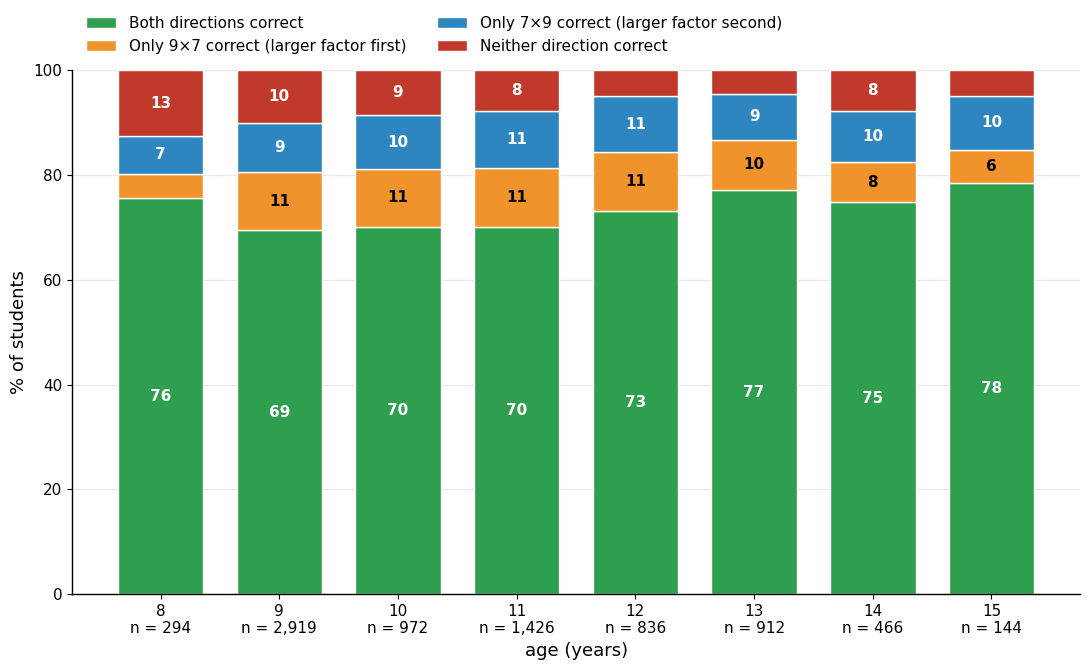

Plot -> descriptive\plots\a998_commutativity_pupil_shares_by_age_en_7x9.png (+ .pdf)
                      pupils  pct_both_right  pct_only_big_first  pct_only_big_second  pct_neither_right
classroom_course_age                                                                                    
8                        294           75.51                4.76                 7.14              12.58
9                       2919           69.41               11.10                 9.46              10.04
10                       972           70.17               11.01                10.18               8.64
11                      1426           70.06               11.22                11.01               7.71
12                       836           73.09               11.36                10.53               5.02
13                       912           77.08                9.65                 8.66               4.61
14                       466           74.89                7.51           

In [6]:
# =============================================================================
# Pupil shares by age, looped over the HARDEST pairs
# =============================================================================
# One stacked bar per age with the four mutually exclusive cases of a paired
# pupil, always up to 100%, drawn for several hard pairs in one loop. Nothing is
# recomputed and no query is fired: it reuses `valid` (the rows that already
# clear MIN_STUDENTS) and `summary` from the cells above.
#
# WHICH PAIRS ARE "HARD" IS READ OFF THE DATA, not hardcoded, so that re-running
# with another YEARS / MIN_ATTEMPTS ranks whatever that population says is hard:
#   1) keep only pairs that clear MIN_STUDENTS at EVERY age of `summary`
#      (a pair missing an age would silently draw a shorter figure -- and the
#      pairs with a 0 or 1 factor are exactly the ones that miss age 8),
#   2) rank them by the UNWEIGHTED mean of pct_both_right across the ages
#      (unweighted: the question is which pair is hard, and age 9 having 30x the
#      pupils of age 15 must not decide it), lowest = hardest,
#   3) take the first N_HARD_PAIRS.
# Set HARD_PAIRS_OVERRIDE to a list of tuples to pick the pairs by hand instead;
# they are normalised to lo <= hi (the query only ever returns that triangle, so
# (8, 6) would match no row at all and the pair would vanish without a word).
N_HARD_PAIRS = 6
HARD_PAIRS_OVERRIDE = None      # e.g. [(6, 8), (7, 8), (4, 8)]

EN_CASES = {
    "pct_both_right":      ("Both directions correct",   "#2E9E4F"),
    "pct_only_big_first":  (None,                        "#F0932B"),   # label per pair
    "pct_only_big_second": (None,                        "#2E86C1"),
    "pct_neither_right":   ("Neither direction correct",  "#C0392B"),
}
MIN_PCT_LABEL_EN = 6.0          # below this the number does not fit in the segment
_thousands = lambda x: f"{int(x):,}"


def _text_color(hex_color):
    """White on the dark fills, black on the light orange."""
    r, g, b = to_rgb(hex_color)
    return "white" if (0.299 * r + 0.587 * g + 0.114 * b) < 0.6 else "black"


def shares_by_age_en(data, big_first, big_second, filename):
    """data: frame indexed by age with the four pct_* columns plus `pupils`.
    big_first / big_second: how to name each direction in the legend."""
    labels = {"pct_only_big_first":  f"Only {big_first} correct (larger factor first)",
              "pct_only_big_second": f"Only {big_second} correct (larger factor second)"}
    ages = data.index.to_numpy()
    x = np.arange(len(ages))

    # The four cases partition the paired pupils; if they do not sum to 100 the
    # stacked bar would be a lie, so stop instead of drawing it.
    total = data[list(EN_CASES)].sum(axis=1)
    assert np.allclose(total, 100, atol=0.05), \
        f"The four cases do not sum to 100 (min {total.min():.2f}, max {total.max():.2f})"

    fig, ax = plt.subplots(figsize=(11, 6.8))
    base = np.zeros(len(ages))
    for col, (fixed_label, color) in EN_CASES.items():
        v = data[col].to_numpy()
        ax.bar(x, v, bottom=base, width=0.72, color=color,
               edgecolor="white", linewidth=1.0, zorder=2,
               label=fixed_label or labels[col])
        for xi, vi, bi in zip(x, v, base):
            if vi >= MIN_PCT_LABEL_EN:
                ax.text(xi, bi + vi / 2, f"{vi:.0f}", ha="center", va="center",
                        fontsize=11, fontweight="bold", color=_text_color(color),
                        zorder=3)
        base += v

    # Bounded partition, so the axis is fixed to 0-100 on purpose: the height of
    # each block is the share, and every bar is comparable across figures.
    ax.set_ylim(0, 100)
    ax.set_yticks(range(0, 101, 20))
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(a)}\nn = {_thousands(data.loc[a, 'pupils'])}"
                        for a in ages], fontsize=11)
    ax.set_xlabel("age (years)", fontsize=13)
    ax.set_ylabel("% of students", fontsize=13)
    ax.tick_params(axis="y", labelsize=11)
    ax.legend(fontsize=11, frameon=False, ncol=2, loc="lower left",
              bbox_to_anchor=(0, 1.005))
    ax.grid(axis="y", color="#E8E8E8", lw=0.9, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("bottom", "left"):
        ax.spines[s].set_color("black")
        ax.spines[s].set_linewidth(1)

    fig.tight_layout()
    out_en = HERE / "plots" / f"{filename}.png"
    for ext in ("png", "pdf"):
        fig.savefig(out_en.with_suffix("." + ext), dpi=300, bbox_inches="tight",
                    facecolor="white")
    plt.show()
    print(f"Plot -> {out_en.relative_to(ROOT)} (+ .pdf)")
    print(data[["pupils", "pct_both_right", "pct_only_big_first",
                "pct_only_big_second", "pct_neither_right"]].round(2).to_string())


# --- pick the hard pairs ----------------------------------------------------
ALL_AGES = set(summary.index)

per_pair = (valid.groupby(["lo", "hi"])
                 .agg(n_ages=("classroom_course_age", "nunique"),
                      both_right=("pct_both_right", "mean"),      # unweighted
                      n_min=("n_students", "min"),
                      n_max=("n_students", "max")))
complete = per_pair[per_pair["n_ages"] == len(ALL_AGES)]
print(f"{len(complete)} / {len(per_pair)} pairs clear MIN_STUDENTS = {MIN_STUDENTS} at all "
      f"{len(ALL_AGES)} ages; the rest are dropped from the ranking (missing at least one age).")
print("\nHardest pairs by mean % of pupils that get BOTH directions right "
      "(unweighted over ages, lowest first):")
print(complete.sort_values("both_right").head(10).round(1).to_string())

if HARD_PAIRS_OVERRIDE is None:
    HARD_PAIRS = list(complete.sort_values("both_right").head(N_HARD_PAIRS).index)
else:
    HARD_PAIRS = [tuple(sorted(p)) for p in HARD_PAIRS_OVERRIDE]

print(f"\nDrawing {len(HARD_PAIRS)} figures: "
      + ", ".join(f"{hi}×{lo}/{lo}×{hi}" for lo, hi in HARD_PAIRS))

# --- one figure per hard pair ----------------------------------------------
# lo / hi are the factors as the query returns them (lo <= hi), so "larger first"
# is always hi x lo (8x6) and "larger second" lo x hi (6x8). A single pair has
# nothing to weight: the row of `valid` for that (pair, age) IS the number.
for lo, hi in HARD_PAIRS:
    lo, hi = sorted((lo, hi))
    d1 = (valid[(valid["lo"] == lo) & (valid["hi"] == hi)]
          .set_index("classroom_course_age")
          .rename(columns={"n_students": "pupils"})
          .sort_index())
    assert len(d1), f"pair {lo}-{hi} matches no row of `valid` -- check lo <= hi"
    missing = sorted(ALL_AGES - set(d1.index))
    assert not missing, (f"pair {lo}-{hi} has no cell above MIN_STUDENTS at ages {missing}; "
                         "the figure would silently drop those bars")

    print(f"\n=== pair {hi}×{lo} / {lo}×{hi} | {len(d1)} ages | "
          f"{_thousands(d1['pupils'].min())}-{_thousands(d1['pupils'].max())} paired pupils per age")
    shares_by_age_en(d1, f"{hi}×{lo}", f"{lo}×{hi}",
                     f"a998_commutativity_pupil_shares_by_age_en_{lo}x{hi}")

## Els valors de `mean_diff` son senyal feble o soroll? (test de permutacio)

**Com es diu el que estem mirant.** `mean_diff` es un **efecte de l'ordre dels
operands** (*operand-order effect*): la mateixa parella de factors, presentada
com $a\times b$ o com $b\times a$, dona precisions diferents. Amb el signe fixat
com el tenim (gran primer menys gran segon) es un **biaix d'ordre**: positiu =
els va millor amb el factor gran davant. `mean_abs_diff` no es un biaix sino una
**inconsistencia intra-alumne davant la commutativitat**: mida del desacord
entre les dues direccions, independentment de cap a on vagi.

**El problema.** El biaix d'ordre surt de l'ordre de 0.01 i la inconsistencia de
l'ordre de 0.1. Amb ~660k observacions aparellades, un 0.01 pot ser
perfectament un efecte real i petit... o pot ser el que qualsevol soroll
produiria. Mirant nomes el numero no es pot distingir, i el contrast amb
`mean_abs_diff` no ajuda: son coses diferents, no la mateixa cosa a dues
escales.

**El null.** En lloc d'assumir una distribucio teorica, la construim amb les
mateixes dades. Si la direccio no importa (hipotesi nul.la), aleshores, per a un
alumne concret i una parella concreta, **quin dels seus intents va anar en quina
direccio es intercanviable**: reetiquetar-los no hauria de canviar res. Aixi que:

1. Per a cada (alumne, parella, edat), agafem els seus intents i les seves
   respostes tal com son. No es toca res del contingut.
2. **Barregem nomes l'etiqueta de direccio** dins d'aquest bloc: quants intents
   van a "gran primer" i quants a "gran segon" es manté igual, pero quins encerts
   cauen a cada banda es re-reparteix a l'atzar.
3. Es recalculen `acc_bf*`, `acc_bs*`, `d*` i `|d*|` i s'agrega igual que
   sempre: els heatmaps per parella i edat, i la mitjana per edat.
4. Es repeteix `N_PERM` vegades. La distribucio dels `mean_diff*` es el que
   veuriem **si la direccio no importes gens**, mantenint intactes la capacitat
   de cada alumne, la dificultat de cada parella, el nombre d'intents i la mida
   de mostra de cada casella.

El pas 2 te forma tancada: si l'alumne ha fet $n$ intents en total amb $k$
encerts i $n_{bf}$ eren en direccio "gran primer", el nombre d'encerts que li
toca a aquella direccio sota el null es una **hipergeometrica** $H(k, n-k,
n_{bf})$ -- exactament "reparteix els $k$ encerts entre les dues direccions
sense reposicio". Per aixo no cal barrejar llistes: es una crida vectoritzada i
els `N_PERM` passis son segons, no minuts.

**El p-valor** es bilateral i empiric, per edat:
$p = (1 + \#\{|mean\_diff^*| \ge |mean\_diff_{obs}|\}) / (1 + N_{PERM})$.
El $+1$ evita $p=0$: amb `N_PERM` finit, el minim que es pot afirmar es
$p < 1/N_{PERM}$.

> **Que NO respon aixo.** Aquest null **no serveix per a `mean_abs_diff`**, i el
> motiu es important: quan un alumne te 1 intent per direccio, permutar les
> etiquetes nomes li pot **canviar el signe** de $d$, mai la magnitud. Com que
> aquest es el cas de gairebe tota la mostra, el `mean_abs_diff*` aleatoritzat
> ha de sortir practicament identic a l'observat -- **no perque la
> inconsistencia sigui senyal, sino per construccio**. El grafic el dibuixa
> igualment perque veure-ho es la millor manera de no oblidar-ho, pero
> interpretar aquella coincidencia com a validacio seria un error. (Hi ha un
> desfasament petit i sistematic -- l'observat queda sempre lleugerament per
> sota del null -- que ve nomes dels alumnes amb intents desiguals entre
> direccions, els unics permutables en magnitud: un indici, no una prova.) Per posar a
> prova `mean_abs_diff` cal un null que trenqui el lligam amb l'operacio
> barrejant les respostes d'un alumne **entre parelles diferents** (i que per
> tant necessita els seus intents agrupats per alumne, no per parella): es la
> continuacio natural i queda pendent.


In [7]:
# --- dades per alumne (perfils de resposta) per poder permutar --------------
# Les mitjanes no es poden permutar: cal el que hi ha a dins. Aquesta query torna
# el mateix univers d'alumnes que la principal, pero desagregat per PERFIL DE
# RESPOSTA (n_bf, ok_bf, n_bs, ok_bs) amb el recompte d'alumnes que el
# comparteixen -- ~15k files en lloc de ~660k, i sense identificadors d'alumne.
# Els marcadors {YEARS} i {MIN_ATTEMPTS} es reescriuen igual que a la principal:
# si els dos fitxers no descriuen la MATEIXA poblacio, el test no compara res.
PROF_SQL_PATH = HERE / "queries" / "a998_commutativity_student_profiles.sql"

prof_raw = PROF_SQL_PATH.read_text(encoding="utf-8")
prof_sql, n_p = re.subn(r">= \d+(\s*-- \{MIN_ATTEMPTS\})",
                        f">= {MIN_ATTEMPTS_PER_DIRECTION}\\1", prof_raw)
assert n_p == 2, f"Esperava 2 marcadors -- {{MIN_ATTEMPTS}}, n'he trobat {n_p}"
prof_sql, n_py = re.subn(r"IN \([^)]*\)(\s*-- \{YEARS\})",
                         f"IN ({years_sql})\\1", prof_sql)
assert n_py == 1, f"Esperava 1 marcador -- {{YEARS}}, n'he trobat {n_py}"
prof_sql = apply_fast_wrong(prof_sql, label=PROF_SQL_PATH.name)

prof = cached_query(PROF_SQL_PATH, CACHE_DIR, sql_text=prof_sql)
print(f"Perfils: {len(prof):,} files | alumnes-observacio: {prof['n_students'].sum():,}"
      f" | cache -> {CACHE_DIR.relative_to(ROOT)}/")

# NOMES les caselles que sobreviuen MIN_STUDENTS, per comparar contra el mateix
# `valid` / `pooled` i no contra una poblacio lleugerament diferent.
keys = valid.set_index(["academic_year_id", "lo", "hi", "classroom_course_age"]).index
prof = prof[prof.set_index(["academic_year_id", "lo", "hi", "classroom_course_age"])
                .index.isin(keys)].reset_index(drop=True)

# Expansio a una fila per alumne: cada alumne ha de permutar independentment.
w = prof["n_students"].to_numpy()
N_BF = np.repeat(prof["n_bf"].to_numpy(), w).astype(np.int64)
N_BS = np.repeat(prof["n_bs"].to_numpy(), w).astype(np.int64)
OK_BF = np.repeat(prof["ok_bf"].to_numpy(), w).astype(np.int64)
OK_BS = np.repeat(prof["ok_bs"].to_numpy(), w).astype(np.int64)
K_TOT = OK_BF + OK_BS            # encerts totals de l'alumne a la parella
N_TOT = N_BF + N_BS
AGE = np.repeat(prof["classroom_course_age"].to_numpy(), w).astype(np.int64)
print(f"Files per alumne despres d'expandir: {len(N_BF):,}")

# Codis per agregar amb bincount (molt mes rapid que un groupby per repeticio)
AGES_PERM = np.array(sorted(np.unique(AGE)))
age_code = np.searchsorted(AGES_PERM, AGE)
AGE_N = np.bincount(age_code, minlength=len(AGES_PERM))


def agg_by_age(d, absd):
    """Mitjana per edat sobre alumnes = la mateixa mitjana ponderada que `summary`."""
    return (np.bincount(age_code, weights=d, minlength=len(AGES_PERM)) / AGE_N,
            np.bincount(age_code, weights=absd, minlength=len(AGES_PERM)) / AGE_N)


# >>> VERIFICACIO: els perfils han de reproduir la query agregada. Si aixo no
# quadra, els perfils descriuen una altra poblacio i tot el test es una fantasia.
d_obs = OK_BF / N_BF - OK_BS / N_BS
obs_by_age = agg_by_age(d_obs, np.abs(d_obs))
gap_diff = np.abs(obs_by_age[0] - summary.loc[AGES_PERM, "mean_diff"].to_numpy()).max()
gap_abs = np.abs(obs_by_age[1] - summary.loc[AGES_PERM, "mean_abs_diff"].to_numpy()).max()
assert gap_diff < 2e-3 and gap_abs < 2e-3, \
    f"Els perfils NO reprodueixen la query agregada (gap {gap_diff:.4f} / {gap_abs:.4f})"
print(f"Verificacio OK: perfils vs query agregada, desviacio maxima per edat "
      f"{max(gap_diff, gap_abs):.5f} (nomes arrodoniment a 4 decimals del SQL).")


Perfils: 6,668 files | alumnes-observacio: 361,339 | cache -> descriptive\cache/
Files per alumne despres d'expandir: 360,677
Verificacio OK: perfils vs query agregada, desviacio maxima per edat 0.00001 (nomes arrodoniment a 4 decimals del SQL).


In [ ]:
# --- el permutador: barreja NOMES l'etiqueta de direccio -------------------
# Per a cada alumne i parella: reparteix els seus K encerts entre les dues
# direccions sense reposicio, mantenint N_BF i N_BS. Aixo es una hipergeometrica,
# i es exactament permutar quines respostes van a quina direccio.
N_PERM = 10000
SEED = 20260730          # llavor fixa: els grafics es poden reproduir

rng = np.random.default_rng(SEED)

def permute_once():
    ok_bf_star = rng.hypergeometric(K_TOT, N_TOT - K_TOT, N_BF)
    d = ok_bf_star / N_BF - (K_TOT - ok_bf_star) / N_BS
    return d, np.abs(d)


null_diff = np.empty((N_PERM, len(AGES_PERM)))
null_abs = np.empty((N_PERM, len(AGES_PERM)))
for r in range(N_PERM):
    d_star, absd_star = permute_once()
    null_diff[r], null_abs[r] = agg_by_age(d_star, absd_star)

obs_diff, obs_abs = obs_by_age

# p bilateral empiric: quantes permutacions donen un biaix igual o mes extrem
p_diff = (1 + (np.abs(null_diff) >= np.abs(obs_diff)).sum(axis=0)) / (1 + N_PERM)
p_abs = (1 + (null_abs >= obs_abs).sum(axis=0)) / (1 + N_PERM)

perm_summary = pd.DataFrame({
    "mean_diff_obs": obs_diff,
    "null_mitjana": null_diff.mean(axis=0),
    "null_p2.5": np.percentile(null_diff, 2.5, axis=0),
    "null_p97.5": np.percentile(null_diff, 97.5, axis=0),
    "p_valor": p_diff,
    "mean_abs_obs": obs_abs,
    "null_abs_mitjana": null_abs.mean(axis=0),
    "p_valor_abs": p_abs,
}, index=AGES_PERM)
perm_summary.index.name = "classroom_course_age"

print(f"NULL A (permutacio de l'etiqueta de direccio) | N_PERM = {N_PERM} | seed = {SEED}")
print(perm_summary.round(4).to_string())

print("\n>>> COM LLEGIR-HO")
print("El null de mean_diff esta centrat a ~0 (ha de ser-ho: la permutacio no")
print("privilegia cap direccio) i la seva amplada 2.5-97.5% diu quant es mou el")
print("biaix nomes per atzar amb aquesta mida de mostra.")
for age in AGES_PERM:
    r = perm_summary.loc[age]
    width = r["null_p97.5"] - r["null_p2.5"]
    veredicte = ("FORA del null" if r["p_valor"] < 0.05 else "dins del null")
    print(f"  edat {age}: obs {r['mean_diff_obs']:+.4f} | null +-"
          f"{width / 2:.4f} | p = {r['p_valor']:.3f} -> {veredicte}")
print("\nI el recordatori del markdown, ara amb numeros: mean_abs_diff observat vs")
print("aleatoritzat es practicament el mateix numero a cada edat")
print(f"(desviacio maxima {np.abs(obs_abs - null_abs.mean(axis=0)).max():.4f}),")
print("perque amb 1 intent per direccio permutar nomes canvia el SIGNE de d.")
print("Aixo NO valida mean_abs_diff: nomes ensenya que aquest null no el pot tocar.")
print("(p_valor_abs es d'UNA cua -- 'mes inconsistencia que l'atzar' -- i surt ~1")
print("perque l'observat queda per SOTA del null, no per sobre.)")
gap = null_abs.mean(axis=0) - obs_abs
print(f"\nDetall que si val la pena: el desfasament va SEMPRE en el mateix sentit,")
print(f"l'observat per sota del null a totes les edats (+{gap.min():.4f} a +{gap.max():.4f}).")
print("Ve de la minoria d'alumnes amb intents desiguals entre direccions (n_bf !=")
print("n_bs), els unics als quals la permutacio SI pot canviar la magnitud de d.")
print("Es un indici -- no una prova -- que part de la consistencia es real: mesurat")
print("sobre nomes aquest subconjunt, i per aixo cal el null entre parelles.")

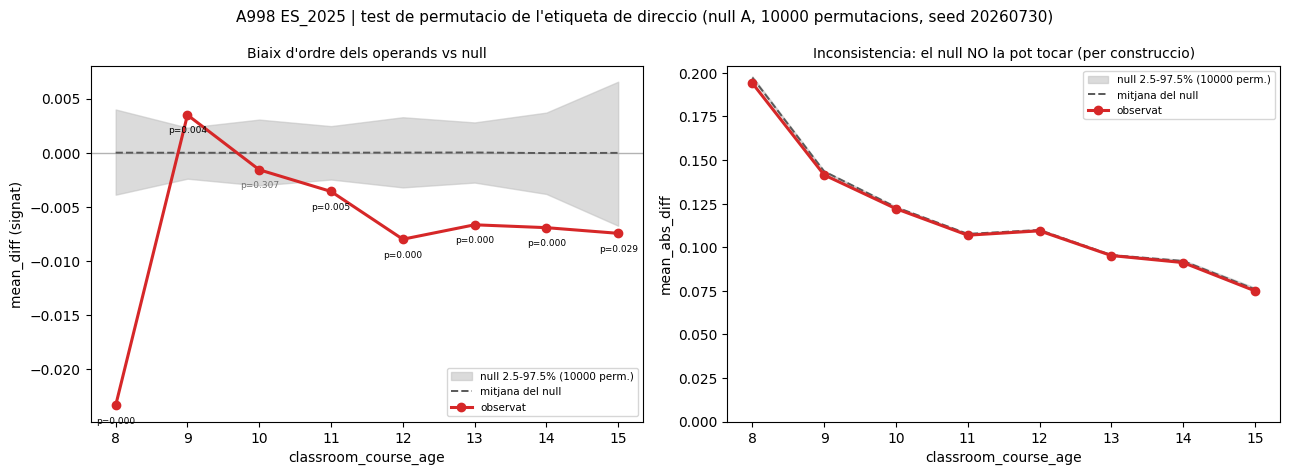

Plot -> descriptive\plots\a998_commutativity_permutation_test.png


In [ ]:
# --- tendencia: observat vs banda nul.la ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].axhline(0, color="0.7", lw=1)
axes[0].fill_between(AGES_PERM, np.percentile(null_diff, 2.5, axis=0),
                     np.percentile(null_diff, 97.5, axis=0),
                     color="0.75", alpha=0.55, label=f"null 2.5-97.5% ({N_PERM} perm.)")
axes[0].plot(AGES_PERM, null_diff.mean(axis=0), "--", lw=1.4, color="0.35",
             label="mitjana del null")
axes[0].plot(AGES_PERM, obs_diff, "o-", lw=2.2, color="tab:red", label="observat")
axes[0].set_ylabel("mean_diff (signat)")
axes[0].set_title("Biaix d'ordre dels operands vs null", fontsize=10)
for age, obs, p in zip(AGES_PERM, obs_diff, p_diff):
    axes[0].annotate(f"p={p:.3f}", (age, obs), textcoords="offset points",
                     xytext=(0, -13), ha="center", fontsize=6.5,
                     color="black" if p < 0.05 else "0.45")

axes[1].fill_between(AGES_PERM, np.percentile(null_abs, 2.5, axis=0),
                     np.percentile(null_abs, 97.5, axis=0),
                     color="0.75", alpha=0.55, label=f"null 2.5-97.5% ({N_PERM} perm.)")
axes[1].plot(AGES_PERM, null_abs.mean(axis=0), "--", lw=1.4, color="0.35",
             label="mitjana del null")
axes[1].plot(AGES_PERM, obs_abs, "o-", lw=2.2, color="tab:red", label="observat")
axes[1].set_ylim(bottom=0)
axes[1].set_ylabel("mean_abs_diff")
axes[1].set_title("Inconsistencia: el null NO la pot tocar (per construccio)", fontsize=10)

for ax in axes:
    ax.set_xlabel("classroom_course_age")
    ax.set_xticks(range(8, 16))
    ax.legend(fontsize=7.5)

fig.suptitle(f"A998 {'+'.join(YEARS)} | test de permutacio de l'etiqueta de direccio "
             f"(null A, {N_PERM} permutacions, seed {SEED})", fontsize=11)
fig.tight_layout()
out_path = HERE / "plots" / "a998_commutativity_permutation_test.png"
fig.savefig(out_path, dpi=130)
plt.show()
print(f"Plot -> {out_path.relative_to(ROOT)}")


# Knowledge symmetry

In [ ]:
# =============================================================================
# SIMETRIA DEL CONEIXEMENT: saben les dues direccions d'una parella commutada
# mes sovint del que saben dues operacions qualssevol igual de dificils?
# =============================================================================

KS_SQL_PATH = HERE / "queries" / "a998_student_fact_last_attempt.sql"
KS_AGES = list(range(8, 16))
KS_MIN_PUPILS_TRAJ = 200    # alumnes minims per (operacio, edat) per fiar-se de la trajectoria
KS_MIN_DENOM = 100          # alumnes minims al denominador (sap com a minim una) per casella
KS_EXCLUDE_RACING = True    # Decisio #12, com a mds_facts.ipynb
KS_ANCHOR_SMALL_FIRST = True   # ancora = factor petit primer (2×7); False -> 7×2

def ks_load(exclude_racing):
    """Mateixa substitucio de marcadors que mds_facts.ipynb (mateix cache, cap
    query nova si ja s'ha executat alla). Cada subn ha de tocar exactament 1 cop:
    si un marcador es mou, aixo peta aqui en lloc de consultar en silenci una
    altra poblacio."""
    raw = KS_SQL_PATH.read_text(encoding="utf-8")
    s, n_y = re.subn(r"IN \([^)]*\)(\s*-- \{YEARS\})", f"IN ({years_sql})\\1", raw)
    s, n_a = re.subn(r"BETWEEN \d+ AND \d+(\s*-- \{AGES\})",
                     f"BETWEEN {KS_AGES[0]} AND {KS_AGES[-1]}\\1", s)
    s, n_p = re.subn(r"AND [^\n]*?(\s*-- \{PACKS\})", r"AND 1 = 1\1", s)
    racing = "racing_sitting = 0" if exclude_racing else "1 = 1"
    s, n_r = re.subn(r"WHERE 1 = 1(\s*-- \{RACING_FILTER\})", f"WHERE {racing}\\1", s)
    assert (n_y, n_a, n_p, n_r) == (1, 1, 1, 1), \
        f"marcadors substituits {(n_y, n_a, n_p, n_r)}, esperava (1, 1, 1, 1)"
    # El filtre de respostes rapides i erronies de la cel.la 0, aqui tambe (seva,
    # 2026-08-25), aixi que aquesta figura surt de la mateixa poblacio que les de
    # dalt. Es SUMA al filtre de racing: una tongada racing cau per la mediana de
    # la tongada, un alumne amb una fallada rapida cau sencer.
    # OJO amb el cache: el .sql ha canviat de text (marcadors nous), aixi que la
    # primera execucio despres del 2026-08-25 torna a llancar la query -- i
    # mds_facts.ipynb, que llegeix el mateix fitxer, tambe ho fara un cop.
    s = apply_fast_wrong(s, label=KS_SQL_PATH.name)
    df = cached_query(KS_SQL_PATH, CACHE_DIR, sql_text=s)
    return df[df["student_age"].between(KS_AGES[0], KS_AGES[-1])]


def ks_matrices(df):
    """Dues matrius alumne × 100 operacions: vista (OBS) i sabuda (KNW).
    Una operacio que l'alumne no ha vist mai es OBS=False, mai KNW=False: un
    forat no es un error (mateix criteri que mds_facts.ipynb)."""
    op = df["factor_1"].to_numpy() * 10 + df["factor_2"].to_numpy()
    sid = df["student_idx"].to_numpy()
    n = int(sid.max()) + 1
    obs = np.zeros((n, 100), bool)
    knw = np.zeros((n, 100), bool)
    age = np.zeros(n, np.int16)
    obs[sid, op] = True
    knw[sid, op] = (df["n_correct_all"].to_numpy() == df["n_attempts"].to_numpy())
    age[sid] = df["student_age"].to_numpy()
    return obs, knw, age


def ks_trajectories(df):
    """error rate per (operacio, edat) sobre TOTS els intents, 1 - correctes/intents.
    NaN quan la casella te menys de KS_MIN_PUPILS_TRAJ alumnes: una trajectoria
    feta amb 2 alumnes (les operacions amb 0 i 1 a edat 8) no es una trajectoria."""
    d = df.assign(op=df["factor_1"] * 10 + df["factor_2"])
    g = (d.groupby(["op", "student_age"], as_index=False)
          .agg(n_att=("n_attempts", "sum"), n_ok=("n_correct_all", "sum"),
               n_pup=("student_idx", "size")))
    g["err"] = 1 - g["n_ok"] / g["n_att"]
    g.loc[g["n_pup"] < KS_MIN_PUPILS_TRAJ, "err"] = np.nan
    return g.pivot(index="op", columns="student_age", values="err").reindex(columns=KS_AGES)


ks_att = ks_load(KS_EXCLUDE_RACING)
KS_OBS, KS_KNW, KS_AGE_OF = ks_matrices(ks_att)
KS_ERR = ks_trajectories(ks_att)
ks_full = KS_ERR.notna().all(axis=1)

print(f"A998 {'+'.join(YEARS)} | simetria del coneixement (gra alumne × operacio)")
print(f"Font: {KS_SQL_PATH.name} | racing {'EXCLOS' if KS_EXCLUDE_RACING else 'inclos'}"
      f" | criteri 'sap' = tots els intents correctes")
print(f"Alumnes: {ks_att['student_idx'].nunique():,} | cel.les alumne × operacio: {len(ks_att):,}")
print(f"Operacions amb trajectoria completa 8-15 (>= {KS_MIN_PUPILS_TRAJ} alumnes a cada edat): "
      f"{int(ks_full.sum())}/100")
print("Sense trajectoria (i per tant fora, com a objectiu i com a control): "
      + ", ".join(f"{o//10}×{o%10}" for o in KS_ERR.index[~ks_full]))

# --- 1) triar el control de cada parella, un sol cop -----------------------
ks_fmt = lambda o: f"{o // 10}×{o % 10}"
KS_PAIRS = [(a, b) for a in range(10) for b in range(a + 1, 10)]

def ks_candidates(a, b):
    """Operacions que comparteixen un factor amb la parella {a,b}, excloent les
    dues direccions de la parella mateixa."""
    return [f1 * 10 + f2 for f1 in range(10) for f2 in range(10)
            if (f1, f2) not in [(a, b), (b, a)] and (a in (f1, f2) or b in (f1, f2))]

def ks_build_match(small_first):
    out = []
    for a, b in KS_PAIRS:
        anchor, twin = ((a * 10 + b, b * 10 + a) if small_first
                        else (b * 10 + a, a * 10 + b))
        if not ks_full.get(anchor, False) or not ks_full.get(twin, False):
            continue                  # parella sense trajectoria fiable (les del 0 i l'1)
        tgt = KS_ERR.loc[anchor].to_numpy()
        cands = [(np.mean((KS_ERR.loc[c].to_numpy() - tgt) ** 2), c)
                 for c in ks_candidates(a, b) if ks_full.get(c, False)]
        dist, ctrl = min(cands)
        out.append(dict(a=a, b=b, anchor=anchor, twin=twin, ctrl=ctrl, dist=dist))
    return pd.DataFrame(out)

ks_match = ks_build_match(KS_ANCHOR_SMALL_FIRST)
print(f"\nParelles commutades amb control assignat: {len(ks_match)} de {len(KS_PAIRS)}")

# --- 2) el indicador, edat per edat, amb el control ja congelat ------------
def ks_ratio(sel, x, y, knw):
    kx, ky = knw[sel, x], knw[sel, y]
    den = int((kx | ky).sum())
    return (100 * int((kx & ky).sum()) / den if den else np.nan), den

def ks_symmetry(obs, knw, age_of, match):
    idx_by_age = {a: np.where(age_of == a)[0] for a in KS_AGES}
    rows = []
    for r in match.itertuples():
        A, T, C = int(r.anchor), int(r.twin), int(r.ctrl)
        for a in KS_AGES:
            s = idx_by_age[a]
            pw_comm = s[obs[s, A] & obs[s, T]]
            pw_ctrl = s[obs[s, A] & obs[s, C]]
            trip = s[obs[s, A] & obs[s, T] & obs[s, C]]
            sym_c, den_c = ks_ratio(pw_comm, A, T, knw)
            sym_k, den_k = ks_ratio(pw_ctrl, A, C, knw)
            tri_c, dtc = ks_ratio(trip, A, T, knw)
            tri_k, dtk = ks_ratio(trip, A, C, knw)
            rows.append(dict(a=r.a, b=r.b, anchor=A, twin=T, ctrl=C, age=a,
                             sym_comm=sym_c, den_comm=den_c,
                             sym_ctrl=sym_k, den_ctrl=den_k,
                             tri_comm=tri_c, tri_ctrl=tri_k,
                             den_trip=min(dtc, dtk),
                             cov_comm=100 * len(pw_comm) / len(s),
                             cov_ctrl=100 * len(pw_ctrl) / len(s)))
    return pd.DataFrame(rows)

ks_raw = ks_symmetry(KS_OBS, KS_KNW, KS_AGE_OF, ks_match)

# PANELL BALANCEJAT: nomes les parelles que arriben a KS_MIN_DENOM a TOTES les
# edats, i les mateixes a totes. Si no, la pujada de la linia podria ser
# nomes que a edat 15 sobreviuen les parelles facils.
ks_keep = ks_raw.groupby("anchor").apply(
    lambda g: bool((g[["den_comm", "den_ctrl"]].min(axis=1) >= KS_MIN_DENOM).all()
                   and g[["sym_comm", "sym_ctrl"]].notna().all().all()),
    include_groups=False)
ks_out = [ks_fmt(o) for o in ks_keep.index[~ks_keep]]
ks = ks_raw[ks_raw["anchor"].isin(ks_keep.index[ks_keep])]
print(f"Panell balancejat: {int(ks_keep.sum())} parelles a les 8 edats"
      + (f" | fora per mostra: {', '.join(ks_out)}" if ks_out else ""))

print("\nControl escollit per parella (congelat per a totes les edats):")
ks_tab = ks_match[ks_match["anchor"].isin(ks.anchor.unique())].copy()
ks_tab["parella"] = [f"{ks_fmt(x)} / {ks_fmt(y)}" for x, y in zip(ks_tab.anchor, ks_tab.twin)]
ks_tab["control"] = [f"{ks_fmt(x)} / {ks_fmt(y)}" for x, y in zip(ks_tab.anchor, ks_tab.ctrl)]
ks_tab["dist_err"] = ks_tab["dist"].map(lambda d: f"{d:.2e}")
print(ks_tab[["parella", "control", "dist_err"]].to_string(index=False))
ks_ties = [ks_fmt(c) for c in ks_tab["ctrl"] if c // 10 == c % 10]
print(f"Controls que son un quadrat (n×n): {len(ks_ties)}"
      + (f" ({', '.join(ks_ties)})" if ks_ties else ""))

# --- 3) mitjana per edat, mateix pes per parella ---------------------------
ks_by_age = (ks.groupby("age")
               .agg(parelles=("anchor", "size"),
                    comm=("sym_comm", "mean"), ctrl=("sym_ctrl", "mean"),
                    den_comm=("den_comm", "mean"), den_ctrl=("den_ctrl", "mean"),
                    tri_comm=("tri_comm", "mean"), tri_ctrl=("tri_ctrl", "mean"),
                    den_trip=("den_trip", "mean")))
ks_by_age["gap"] = ks_by_age["comm"] - ks_by_age["ctrl"]
ks_by_age["gap_trip"] = ks_by_age["tri_comm"] - ks_by_age["tri_ctrl"]

print("\n% que sap les DUES entre els que en sap com a minim UNA (mitjana simple"
      " entre parelles):")
print(ks_by_age[["parelles", "comm", "ctrl", "gap", "den_comm", "den_ctrl"]]
      .round(2).to_string())
print("\nMateixos ALUMNES als dos costats (els que han vist les tres operacions)"
      " -- comprovacio, mateixes parelles:")
print(ks_by_age[["tri_comm", "tri_ctrl", "gap_trip", "den_trip"]].round(2).to_string())

print("\n% dels alumnes de cada edat que han vist les DUES operacions de cada"
      " comparacio (mitjana entre parelles):")
print(ks.groupby("age")[["cov_comm", "cov_ctrl"]].mean().round(1).to_string())
print("A edat 8 els packs donen molt poques vegades les dues orientacions de la")
print("mateixa parella, aixi que la casella de la parella commutada es un")
print("subconjunt petit i seleccionat del curs -- llegeix l'edat 8 amb aixo al cap.")

# ROBUSTESA A L'ANCORA: la parella commutada es simetrica, pero el control
# s'aparella a UNA de les dues direccions. Es repeteix tot amb l'altra ancora.
ks_flip = ks_symmetry(KS_OBS, KS_KNW, KS_AGE_OF, ks_build_match(not KS_ANCHOR_SMALL_FIRST))
ks_flip_keep = ks_flip.groupby("anchor").apply(
    lambda g: bool((g[["den_comm", "den_ctrl"]].min(axis=1) >= KS_MIN_DENOM).all()
                   and g[["sym_comm", "sym_ctrl"]].notna().all().all()),
    include_groups=False)
ks_flip = ks_flip[ks_flip["anchor"].isin(ks_flip_keep.index[ks_flip_keep])]
ks_flip_by_age = ks_flip.groupby("age").agg(comm=("sym_comm", "mean"),
                                            ctrl=("sym_ctrl", "mean"))
ks_flip_by_age["gap"] = ks_flip_by_age["comm"] - ks_flip_by_age["ctrl"]
print("\nAmb l'ALTRA ancora (" + ("gran primer" if KS_ANCHOR_SMALL_FIRST else "petit primer")
      + f", {len(ks_flip.anchor.unique())} parelles):")
print(ks_flip_by_age.round(2).to_string())
print("La linia commutada es identica per construccio (la parella no te ordre);")
print("el que canvia es el control. De 9 a 15 anys la distancia es la mateixa; a")
print("edat 8 canvia de signe, o sigui que el numero d'edat 8 NO es interpretable.")

# --- 4) VERIFICACIO: el criteri es el mateix que el de la query agregada? ---
# Amb racing INCLOS, symmetric_comm ha de reproduir la query casella per casella
# (pct_both_right / (100 - pct_neither_right) es literalment "sap les dues entre
# els que en sap una"). Es la prova que "sap una operacio" vol dir el mateix als
# dos calculs. Es fa amb racing inclos perque la query agregada no el filtra.
ks_att_all = ks_load(exclude_racing=False)
KS_OBS_A, KS_KNW_A, KS_AGE_A = ks_matrices(ks_att_all)
ks_chk = ks_symmetry(KS_OBS_A, KS_KNW_A, KS_AGE_A, ks_match)
ks_q = valid.assign(sym_query=lambda d: 100 * d["pct_both_right"]
                    / (100 - d["pct_neither_right"]))
ks_cmp = (ks_chk.merge(ks_q[["lo", "hi", "classroom_course_age", "sym_query", "n_students"]],
                       left_on=["a", "b", "age"],
                       right_on=["lo", "hi", "classroom_course_age"])
                .assign(gap=lambda d: (d["sym_comm"] - d["sym_query"]).abs()))
print(f"\nVERIFICACIO vs la query agregada ({len(ks_cmp)} caselles parella × edat, racing inclos):")
print(f"  desviacio maxima {ks_cmp['gap'].max():.3f} pp | mitjana {ks_cmp['gap'].mean():.4f} pp")
assert ks_cmp["gap"].max() < 0.5, \
    ("El criteri 'sap una operacio' NO coincideix amb pct_both_right de la query "
     f"(desviacio {ks_cmp['gap'].max():.2f} pp). No llegeixis el grafic.")
print("  OK: mateix criteri, mateixa poblacio. La diferencia amb el numero de la")
print("  taula de dalt es NOMES el filtre de racing:")
ks_racing = (ks_chk[ks_chk["anchor"].isin(ks.anchor.unique())].groupby("age")
             .agg(comm=("sym_comm", "mean"), ctrl=("sym_ctrl", "mean")))
ks_racing["gap"] = ks_racing["comm"] - ks_racing["ctrl"]
print(ks_racing.round(2).to_string())
print("  (el nivell baixa ~3 pp amb racing inclos, pero la DISTANCIA entre linies"
      " -- l'unic que es llegeix -- gairebe no es mou.)")

# --- 5) bandes de confiança per bootstrap ---------------------------------
# DUES fonts d'incertesa, i responen preguntes diferents, aixi que es fan les dues:
#
# (a) BOOTSTRAP D'ALUMNES (les bandes del grafic). Es remostregen els alumnes DINS
#     de cada edat, mantenint les 28 parelles fixes. Un alumne entra o surt SENCER,
#     amb el mateix pes a totes les parelles on apareix -- es un bootstrap
#     CLUSTERITZAT per alumne, que es el que toca: el mateix nen contribueix a
#     moltes parelles i tractar cada casella com a independent estretaria les
#     bandes artificialment.
#     Pesos de Poisson(1) en lloc de remostreig multinomial: son equivalents amb
#     mostres grans i, com que el numerador i el denominador de cada parella son
#     sumes sobre alumnes, tot el remostreig es un producte de matrius
#     (parelles × alumnes) @ (alumnes × repeticions) -- KS_N_BOOT repeticions en
#     segons en lloc de minuts. Es fa per trossos de KS_BOOT_CHUNK per no muntar
#     una matriu de pesos de centenars de MB.
#
# (b) BOOTSTRAP DE PARELLES (nomes imprès). Es remostregen les 28 parelles amb
#     reposicio: respon "aquesta diferencia es de les operacions concretes que han
#     entrat o generalitza als fets?". Es sempre mes ampla que (a) i es la mes
#     conservadora de les dues; per aixo l'asterisc del grafic la fa servir.
#
# COM LLEGIR LES BANDES: son MARGINALS (una per linia). No es poden creuar amb
# l'ull per decidir si la diferencia es real, perque les dues linies es calculen
# sobre alumnes que se solapen -- comparteixen l'ancora. La inferencia correcta es
# l'IC de la DIFERENCIA aparellada, que es calcula dins de la mateixa repeticio i
# surt a la taula (i es mes estret que la distancia entre bandes).
KS_N_BOOT = 1000
KS_BOOT_SEED = 20260814     # llavor fixa i propia (no la del test de permutacio)
KS_BOOT_CHUNK = 100         # repeticions per tros, per acotar la memoria

ks_rng = np.random.default_rng(KS_BOOT_SEED)
ks_m = ks_match[ks_match["anchor"].isin(ks.anchor.unique())]
KS_A = ks_m["anchor"].to_numpy()
KS_T = ks_m["twin"].to_numpy()
KS_C = ks_m["ctrl"].to_numpy()

ks_boot = {}
for a in KS_AGES:
    S = np.where(KS_AGE_OF == a)[0]
    o, k = KS_OBS[S], KS_KNW[S]
    obs_c = o[:, KS_A] & o[:, KS_T]          # ha vist les dues direccions
    obs_k = o[:, KS_A] & o[:, KS_C]          # ha vist ancora i control
    kA, kT, kC = k[:, KS_A], k[:, KS_T], k[:, KS_C]
    NUMC = (obs_c & kA & kT).T.astype(np.float32)
    DENC = (obs_c & (kA | kT)).T.astype(np.float32)
    NUMK = (obs_k & kA & kC).T.astype(np.float32)
    DENK = (obs_k & (kA | kC)).T.astype(np.float32)
    cc, kk, gg, done = [], [], [], 0
    while done < KS_N_BOOT:
        b = min(KS_BOOT_CHUNK, KS_N_BOOT - done)
        done += b
        W = ks_rng.poisson(1.0, size=(len(S), b)).astype(np.float32)
        rc = 100 * (NUMC @ W) / np.maximum(DENC @ W, 1e-9)
        rk = 100 * (NUMK @ W) / np.maximum(DENK @ W, 1e-9)
        cc.append(rc.mean(axis=0))           # mitjana entre parelles, mateix pes
        kk.append(rk.mean(axis=0))
        gg.append((rc - rk).mean(axis=0))    # diferencia DINS de la repeticio
    ks_boot[a] = tuple(np.concatenate(x) for x in (cc, kk, gg))

ks_ci = pd.DataFrame([
    dict(age=a,
         comm_lo=np.percentile(ks_boot[a][0], 2.5), comm_hi=np.percentile(ks_boot[a][0], 97.5),
         ctrl_lo=np.percentile(ks_boot[a][1], 2.5), ctrl_hi=np.percentile(ks_boot[a][1], 97.5),
         gap_lo=np.percentile(ks_boot[a][2], 2.5), gap_hi=np.percentile(ks_boot[a][2], 97.5))
    for a in KS_AGES]).set_index("age")

# (b) bootstrap sobre les PARELLES, amb els seus valors observats
ks_gap_pairs = (ks.pivot_table(index="anchor", columns="age", values="sym_comm")
                - ks.pivot_table(index="anchor", columns="age", values="sym_ctrl"))
ks_rng_p = np.random.default_rng(KS_BOOT_SEED + 1)
ks_draw = ks_rng_p.integers(0, len(ks_gap_pairs), size=(KS_N_BOOT, len(ks_gap_pairs)))
ks_pair_boot = ks_gap_pairs.to_numpy()[ks_draw].mean(axis=1)
ks_ci["gapP_lo"] = np.percentile(ks_pair_boot, 2.5, axis=0)
ks_ci["gapP_hi"] = np.percentile(ks_pair_boot, 97.5, axis=0)

print(f"\nBOOTSTRAP | {KS_N_BOOT} repeticions | seed {KS_BOOT_SEED}"
      " | IC empiric 2,5-97,5%")
print("comm/ctrl_lo-hi i gap_lo-hi: remostrejant ALUMNES (bandes del grafic)."
      " gapP: remostrejant PARELLES.")
ks_show = ks_ci.join(ks_by_age[["comm", "ctrl", "gap"]])
print(ks_show[["comm", "comm_lo", "comm_hi", "ctrl", "ctrl_lo", "ctrl_hi",
               "gap", "gap_lo", "gap_hi", "gapP_lo", "gapP_hi"]].round(2).to_string())
ks_sig = (ks_ci["gapP_lo"] > 0) | (ks_ci["gapP_hi"] < 0)
print("Edats amb l'IC de la diferencia (bootstrap de PARELLES, el conservador)"
      f" fora del 0: {', '.join(str(a) for a in ks_ci.index[ks_sig])}")

A998 ES_2025 | simetria del coneixement (gra alumne × operacio)
Font: a998_student_fact_last_attempt.sql | racing EXCLOS | criteri 'sap' = tots els intents correctes
Alumnes: 124,663 | cel.les alumne × operacio: 2,752,586
Operacions amb trajectoria completa 8-15 (>= 200 alumnes a cada edat): 72/100
Sense trajectoria (i per tant fora, com a objectiu i com a control): 0×0, 0×1, 0×2, 0×3, 0×4, 0×5, 0×6, 0×7, 0×8, 0×9, 1×0, 1×1, 2×0, 2×1, 3×0, 3×1, 4×0, 4×1, 5×0, 5×1, 6×0, 6×1, 7×0, 7×1, 8×0, 8×1, 9×0, 9×1

Parelles commutades amb control assignat: 28 de 45
Panell balancejat: 28 parelles a les 8 edats

Control escollit per parella (congelat per a totes les edats):
  parella   control dist_err
2×3 / 3×2 2×3 / 2×4 4.06e-05
2×4 / 4×2 2×4 / 2×3 4.06e-05
2×5 / 5×2 2×5 / 5×4 4.12e-05
2×6 / 6×2 2×6 / 2×7 7.75e-05
2×7 / 7×2 2×7 / 2×9 1.42e-05
2×8 / 8×2 2×8 / 2×6 1.80e-04
2×9 / 9×2 2×9 / 2×7 1.42e-05
3×4 / 4×3 3×4 / 3×5 3.01e-04
3×5 / 5×3 3×5 / 4×5 1.31e-04
3×6 / 6×3 3×6 / 4×6 2.17e-04
3×7 / 7×3 3×

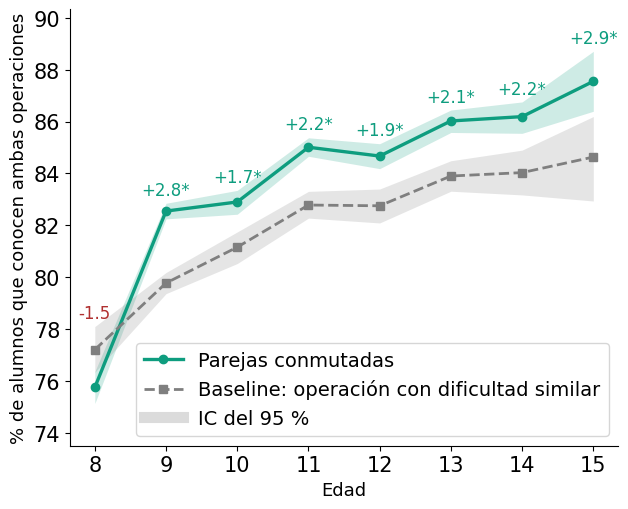


Plot -> descriptive\plots\a998_commutativity_knowledge_symmetry.png
>>> LECTURA: de 9 a 15 anys la parella commutada esta entre +1.7 i +2.9 pp per sobre del control aparellat, sense tendencia clara: el que la commutativa afegeix per sobre de
    'qui sap una operacio d'aquest nivell sol saber-ne una altra del mateix
    factor' es petit pero constant, i NO creix amb l'edat -- el que creix es
    el nivell de les dues linies. A edat 8 el signe depen de quina direccio
    s'agafa com a ancora (-1.5 pp aqui, +2.9 pp amb l'altra), aixi que d'aquella edat
    nomes se'n pot dir que no hi ha cap avantatge commutatiu detectable
    (IC de parelles a edat 8: [-4.7, +1.8] pp, amb el 0 a dins).


In [ ]:
# --- 6) el grafic ----------------------------------------------------------
# Mides de lletra del grafic (edita aqui, no mes avall)
KS_LEGEND_SIZE = 14    # llegenda ("Parejas conmutadas...", "Baseline...", "IC 95%...")
KS_ANNOT_SIZE = 12     # numeros de diferencia sobre cada punt (+3,1*, -1,2...)
KS_LABEL_SIZE = 13    # etiquetes dels eixos ("Edad...", "% que sabe...") -- abans no en tenien, sortien per defecte
KS_TICK_SIZE = 15     # numeros dels eixos (les edats 8-15, els percentatges) -- abans tambe per defecte
KS_COMM_COLOR = "#0e9d7f"
KS_CTRL_COLOR = "#7f7f7f"

fig, ax = plt.subplots(figsize=(6.4, 5.2))
# Fons: el rectangle del panell (ax.patch) va BLANC i el de la figura
# (fig.patch) transparent -- son dues coses diferents; per aixo NO es fa
# servir savefig(transparent=True), que buidaria els dos alhora.
ax.set_facecolor("white")

ks_x = ks_by_age.index.to_numpy()
ax.fill_between(ks_x, ks_ci["comm_lo"], ks_ci["comm_hi"], color=KS_COMM_COLOR,
                alpha=0.20, lw=0)
ax.fill_between(ks_x, ks_ci["ctrl_lo"], ks_ci["ctrl_hi"], color=KS_CTRL_COLOR,
                alpha=0.20, lw=0)
ax.plot(ks_x, ks_by_age["comm"], "o-", lw=2.4, ms=6, color=KS_COMM_COLOR,
        label="Parejas conmutadas")
ax.plot(ks_x, ks_by_age["ctrl"], "s--", lw=2.0, ms=5.5, color=KS_CTRL_COLOR,
        label="Baseline: operación con dificultad similar")
ax.plot([], [], color="0.6", alpha=0.35, lw=8,
        label=f"IC del 95 %")
for xi, c, k in zip(ks_x, ks_by_age["comm"], ks_by_age["ctrl"]):
    star = "*" if ks_sig.loc[xi] else ""
    ax.annotate(f"{c - k:+.1f}{star}", (xi, max(ks_ci['comm_hi'].loc[xi], ks_ci['ctrl_hi'].loc[xi])),
                textcoords="offset points", xytext=(0, 6), ha="center",
                fontsize=KS_ANNOT_SIZE,
                color=KS_COMM_COLOR if c >= k else "#b03030")
ax.margins(y=0.12)
ax.set_xticks(KS_AGES)
ax.set_xlabel("Edad", fontsize=KS_LABEL_SIZE)
ax.set_ylabel("% de alumnos que conocen ambas operaciones", fontsize=KS_LABEL_SIZE)
ax.tick_params(axis="both", labelsize=KS_TICK_SIZE)
ax.legend(fontsize=KS_LEGEND_SIZE, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

# Nomes el fons de la FIGURA es transparent (el que envolta el panell); el
# rectangle interior ja s'ha pintat de blanc a dalt amb set_facecolor. Aqui
# fig.patch.set_facecolor("none") + facecolor="none" al savefig es el que
# escriu el canal alfa al PNG -- si es deixa a "auto" agafaria blanc.
fig.patch.set_facecolor("none")
ks_out_path = HERE / "plots" / "a998_commutativity_knowledge_symmetry.png"
fig.savefig(ks_out_path, dpi=130, facecolor="none")
plt.show()
print(f"\nPlot -> {ks_out_path.relative_to(ROOT)}")

ks_g = ks_by_age["gap"]
print(f">>> LECTURA: de 9 a 15 anys la parella commutada esta entre"
      f" {ks_g.loc[9:].min():+.1f} i {ks_g.loc[9:].max():+.1f} pp per sobre del control"
      " aparellat, sense tendencia clara: el que la commutativa afegeix per sobre de")
print("    'qui sap una operacio d'aquest nivell sol saber-ne una altra del mateix")
print("    factor' es petit pero constant, i NO creix amb l'edat -- el que creix es")
print("    el nivell de les dues linies. A edat 8 el signe depen de quina direccio")
print(f"    s'agafa com a ancora ({ks_g.loc[8]:+.1f} pp aqui,"
      f" {ks_flip_by_age['gap'].loc[8]:+.1f} pp amb l'altra), aixi que d'aquella edat")
print("    nomes se'n pot dir que no hi ha cap avantatge commutatiu detectable")
print(f"    (IC de parelles a edat 8: [{ks_ci['gapP_lo'].loc[8]:+.1f}, "
      f"{ks_ci['gapP_hi'].loc[8]:+.1f}] pp, amb el 0 a dins).")

Parelles ordenades per error rate mitja (les dues direccions, edats 8-15):
  6×8: 0.260 | 7×8: 0.252 | 4×8: 0.221 | 6×9: 0.197 | 7×9: 0.190 | 6×7: 0.184 | 4×7: 0.180 | 8×9: 0.170

=== DIFICILS (6,7,8,9) | 6 parella(es): 6×7/7×6 vs 4×7, 6×8/8×6 vs 7×8, 6×9/9×6 vs 7×9, 7×8/8×7 vs 6×8, 7×9/9×7 vs 6×9, 8×9/9×8 vs 4×9
     parelles   comm   ctrl  den_comm  den_ctrl   gap
age                                                  
8           6  76.67  70.17    443.67    685.67  6.49
9           6  76.28  70.80   2591.00   2669.17  5.48
10          6  76.42  72.26    908.00    936.83  4.16
11          6  78.10  73.72   1287.00   1280.33  4.38
12          6  77.50  74.13    762.67    786.17  3.37
13          6  78.09  73.17    882.00    883.00  4.92
14          6  78.50  73.73    461.00    461.00  4.77
15          6  80.00  74.47    125.67    120.00  5.53
* = IC 95% de la diferencia remostrejant PARELLES | edats amb el 0 fora: 8, 9, 10, 11, 12, 13, 14, 15


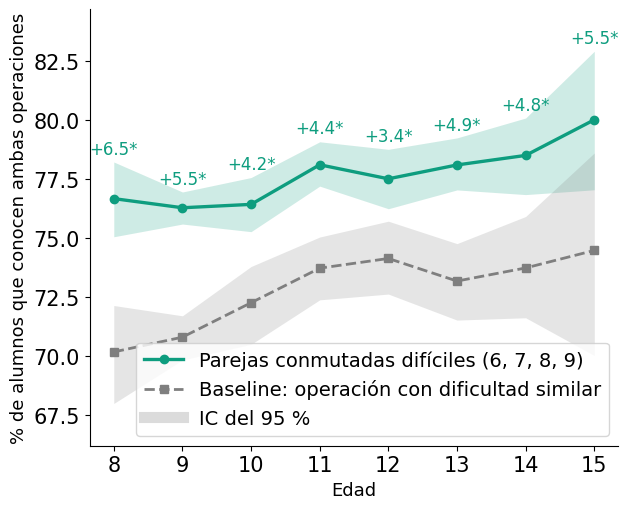

Plot -> descriptive\plots\a998_commutativity_knowledge_symmetry_hard.png

=== FACILS (2,4,5) | 3 parella(es): 2×4/4×2 vs 2×3, 2×5/5×2 vs 5×4, 4×5/5×4 vs 3×5
     parelles   comm   ctrl  den_comm  den_ctrl   gap
age                                                  
8           3  80.35  80.87   4698.33   3581.67 -0.52
9           3  90.55  88.95   3302.00   3231.67  1.60
10          3  90.14  89.30   1144.00   1126.00  0.84
11          3  92.49  91.38   1534.67   1542.67  1.10
12          3  92.41  91.47    888.67    899.00  0.94
13          3  94.16  93.43   1053.67   1020.67  0.73
14          3  94.25  94.11    540.33    540.33  0.14
15          3  93.26  90.45    139.33    137.00  2.81
* = IC 95% de la diferencia remostrejant PARELLES | edats amb el 0 fora: 9, 11


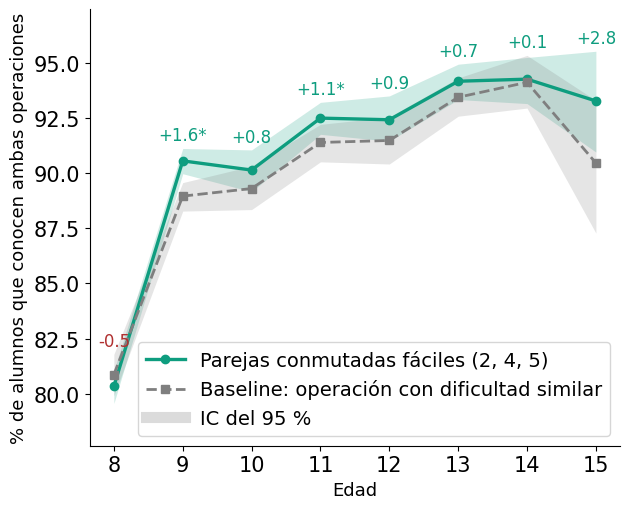

Plot -> descriptive\plots\a998_commutativity_knowledge_symmetry_easy.png

=== UNA SOLA PARELLA 6-8 | 1 parella(es): 6×8/8×6 vs 7×8
     parelles   comm   ctrl  den_comm  den_ctrl   gap
age                                                  
8           1  66.92  57.62     523.0    1456.0  9.30
9           1  73.60  65.50    2352.0    2490.0  8.09
10          1  76.60  68.00     842.0     903.0  8.61
11          1  75.47  70.83    1162.0    1200.0  4.64
12          1  77.78  70.94     756.0     826.0  6.83
13          1  74.59  69.12     846.0     855.0  5.46
14          1  73.76  71.95     423.0     435.0  1.80
15          1  75.24  67.74     105.0     124.0  7.50
* = IC 95% de la diferencia remostrejant ALUMNES (una sola parella) | edats amb el 0 fora: 8, 9, 10, 11, 12, 13


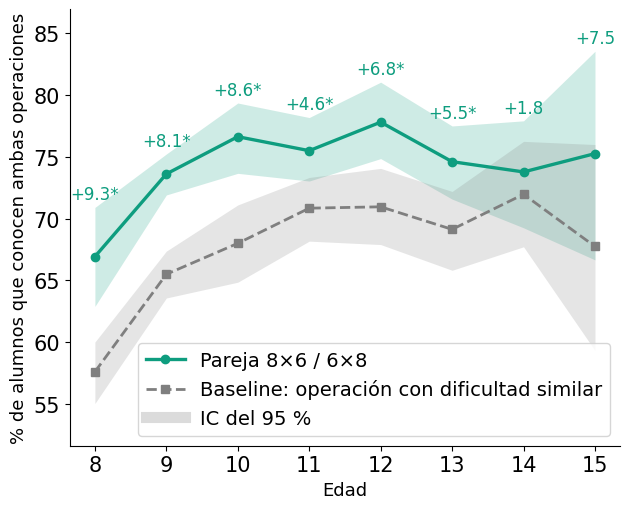

Plot -> descriptive\plots\a998_commutativity_knowledge_symmetry_6x8.png

Distancia (pp) entre la parella commutada i el seu control, per grup:
     totes  dificils  facils   8x6
age                               
8    -1.45      6.49   -0.52  9.30
9     2.77      5.48    1.60  8.09
10    1.74      4.16    0.84  8.61
11    2.23      4.38    1.10  4.64
12    1.92      3.37    0.94  6.83
13    2.12      4.92    0.73  5.46
14    2.16      4.77    0.14  1.80
15    2.92      5.53    2.81  7.50

Nivell de la linia commutada, per grup (per situar les distancies):
     totes  dificils  facils   8x6
age                               
8     75.8      76.7    80.3  66.9
9     82.6      76.3    90.6  73.6
10    82.9      76.4    90.1  76.6
11    85.0      78.1    92.5  75.5
12    84.7      77.5    92.4  77.8
13    86.0      78.1    94.2  74.6
14    86.2      78.5    94.3  73.8
15    87.5      80.0    93.3  75.2


In [ ]:
# =============================================================================
# SIMETRIA DEL CONEIXEMENT, SEPARADA PER DIFICULTAT (seva, 2026-08-25)
# =============================================================================
# La figura de dalt (totes les parelles juntes) NO es toca: es queda tal com
# esta, i aquesta cel.la dibuixa el MATEIX grafic -- mateix indicador, mateix
# control congelat, mateixes bandes, mateix estil -- per subconjunts de parelles:
#
#   DIFICILS   les dues xifres a {6, 7, 8, 9}   -> 6 parelles (6-7 ... 8-9)
#   FACILS     les dues xifres a {2, 4, 5}      -> 3 parelles (2-4, 2-5, 4-5)
#   UNA SOLA   la parella mes dificil de totes  -> 1 parella
#
# RES ES RECALCULA DES DE ZERO: es reutilitzen `ks` (el panell balancejat, ja
# filtrat per KS_MIN_DENOM a totes les edats), `ks_match` (els controls, triats
# UNA vegada amb totes les parelles i congelats) i les matrius KS_OBS / KS_KNW /
# KS_AGE_OF. Cap query nova. Important: el control de cada parella es el que ja
# tenia -- NO es re-tria dins del subgrup, si no la linia baixa canviaria de
# significat entre figures.
#
# QUE NO COBREIXEN AQUESTES DUES CLASSES: les xifres 0, 1 i 3 no son a cap dels
# dos grups, i les parelles mixtes (p.ex. 4-8, facil x dificil) tampoc. Les dues
# figures NO sumen la figura de totes les parelles; son dos extrems.
#
# LA MOSTRA ES MOLT MES PETITA, sobretot a la figura d'una sola parella: la
# mitjana entre parelles amortiguava el soroll i aqui ja no hi es. Per aixo cada
# figura imprimeix els denominadors (alumnes que han vist les dues operacions) i
# les bandes son visiblement mes amples que a la figura de totes.
#
# L'ASTERISC canvia de font segons el subgrup, i cal saber-ho:
#   . amb mes d'una parella -> IC de la diferencia remostrejant PARELLES (el
#     conservador, el mateix criteri que la figura de totes).
#   . amb UNA sola parella -> el bootstrap de parelles no existeix (remostrejar
#     un element no te variabilitat), aixi que s'usa l'IC de la diferencia
#     remostrejant ALUMNES. Es mes estret: NO es comparable amb l'asterisc de
#     les altres figures, i nomes diu "amb aquests alumnes", no "amb aquests fets".
KS_HARD_DIGITS = {6, 7, 8, 9}
KS_EASY_DIGITS = {2, 4, 5}
KS_SINGLE_PAIR = None      # None = la mes dificil segons l'error rate; o p.ex. (6, 8)

# nomes parelles del panell balancejat de la figura de dalt
ks_bal = ks_match[ks_match["anchor"].isin(ks.anchor.unique())].copy()


def ks_group(digits):
    """Files de ks_bal amb LES DUES xifres dins del conjunt donat."""
    return ks_bal[[a in digits and b in digits
                   for a, b in zip(ks_bal["a"], ks_bal["b"])]]


# --- la parella mes dificil: es tria per ERROR RATE, no pel co-coneixement ---
# Deliberat: si es triés per la variable que despres es dibuixa, la figura seria
# el resultat de la seleccio. L'error rate ve de KS_ERR (mateixa font que el
# matching dels controls) i es promitja les dues direccions i les 8 edats.
ks_bal["err_pair"] = [
    float(np.nanmean((KS_ERR.loc[int(t)].to_numpy() + KS_ERR.loc[int(w)].to_numpy()) / 2))
    for t, w in zip(ks_bal["anchor"], ks_bal["twin"])]
ks_hardest = ks_bal.sort_values("err_pair", ascending=False)
print("Parelles ordenades per error rate mitja (les dues direccions, edats 8-15):")
print("  " + " | ".join(f"{ks_fmt(int(r.anchor))}: {r.err_pair:.3f}"
                        for r in ks_hardest.head(8).itertuples()))

if KS_SINGLE_PAIR is None:
    ks_single_row = ks_hardest.iloc[[0]]
else:
    lo, hi = sorted(KS_SINGLE_PAIR)
    ks_single_row = ks_bal[(ks_bal["a"] == lo) & (ks_bal["b"] == hi)]
    assert len(ks_single_row) == 1, \
        f"la parella {lo}-{hi} no es al panell balancejat: {sorted(zip(ks_bal.a, ks_bal.b))}"


def ks_bootstrap(match_sub, seed=KS_BOOT_SEED):
    """Mateix bootstrap clusteritzat per alumne de la cel.la de simetria (pesos de
    Poisson(1), per trossos), pero nomes amb les parelles de match_sub. Torna
    l'IC de les dues linies i el de la diferencia, calculada DINS de cada
    repeticio (aparellada, no la resta de dos ICs)."""
    A = match_sub["anchor"].to_numpy()
    T = match_sub["twin"].to_numpy()
    C = match_sub["ctrl"].to_numpy()
    rng = np.random.default_rng(seed)
    rows = []
    for a in KS_AGES:
        S = np.where(KS_AGE_OF == a)[0]
        o, k = KS_OBS[S], KS_KNW[S]
        obs_c = o[:, A] & o[:, T]
        obs_k = o[:, A] & o[:, C]
        kA, kT, kC = k[:, A], k[:, T], k[:, C]
        NUMC = (obs_c & kA & kT).T.astype(np.float32)
        DENC = (obs_c & (kA | kT)).T.astype(np.float32)
        NUMK = (obs_k & kA & kC).T.astype(np.float32)
        DENK = (obs_k & (kA | kC)).T.astype(np.float32)
        cc, kk, gg, done = [], [], [], 0
        while done < KS_N_BOOT:
            b = min(KS_BOOT_CHUNK, KS_N_BOOT - done)
            done += b
            W = rng.poisson(1.0, size=(len(S), b)).astype(np.float32)
            rc = 100 * (NUMC @ W) / np.maximum(DENC @ W, 1e-9)
            rk = 100 * (NUMK @ W) / np.maximum(DENK @ W, 1e-9)
            cc.append(rc.mean(axis=0))
            kk.append(rk.mean(axis=0))
            gg.append((rc - rk).mean(axis=0))
        c, k_, g = (np.concatenate(x) for x in (cc, kk, gg))
        rows.append(dict(age=a,
                         comm_lo=np.percentile(c, 2.5), comm_hi=np.percentile(c, 97.5),
                         ctrl_lo=np.percentile(k_, 2.5), ctrl_hi=np.percentile(k_, 97.5),
                         gap_lo=np.percentile(g, 2.5), gap_hi=np.percentile(g, 97.5)))
    return pd.DataFrame(rows).set_index("age")


def ks_pair_bootstrap(anchors, seed=KS_BOOT_SEED + 1):
    """IC de la diferencia remostrejant PARELLES (nomes si n'hi ha mes d'una)."""
    gaps = (ks[ks["anchor"].isin(anchors)]
            .pivot_table(index="anchor", columns="age", values="sym_comm")
            - ks[ks["anchor"].isin(anchors)]
            .pivot_table(index="anchor", columns="age", values="sym_ctrl"))
    if len(gaps) < 2:
        return None
    rng = np.random.default_rng(seed)
    draw = rng.integers(0, len(gaps), size=(KS_N_BOOT, len(gaps)))
    boot = gaps.to_numpy()[draw].mean(axis=1)
    return pd.DataFrame({"gapP_lo": np.percentile(boot, 2.5, axis=0),
                         "gapP_hi": np.percentile(boot, 97.5, axis=0)},
                        index=gaps.columns)


def ks_plot_group(match_sub, comm_label, filename, title_note):
    """Mateix grafic que la figura de totes les parelles, amb les de match_sub."""
    anchors = match_sub["anchor"].to_numpy()
    sub = ks[ks["anchor"].isin(anchors)]
    by_age = (sub.groupby("age")
                 .agg(parelles=("anchor", "size"),
                      comm=("sym_comm", "mean"), ctrl=("sym_ctrl", "mean"),
                      den_comm=("den_comm", "mean"), den_ctrl=("den_ctrl", "mean")))
    by_age["gap"] = by_age["comm"] - by_age["ctrl"]
    ci = ks_bootstrap(match_sub)
    pair_ci = ks_pair_bootstrap(anchors)
    if pair_ci is None:                       # una sola parella: IC d'alumnes
        sig = (ci["gap_lo"] > 0) | (ci["gap_hi"] < 0)
        sig_kind = "IC 95% de la diferencia remostrejant ALUMNES (una sola parella)"
    else:
        ci = ci.join(pair_ci)
        sig = (ci["gapP_lo"] > 0) | (ci["gapP_hi"] < 0)
        sig_kind = "IC 95% de la diferencia remostrejant PARELLES"

    print(f"\n=== {title_note} | {len(anchors)} parella(es): "
          + ", ".join(f"{ks_fmt(int(r.anchor))}/{ks_fmt(int(r.twin))} vs {ks_fmt(int(r.ctrl))}"
                      for r in match_sub.itertuples()))
    print(by_age.round(2).to_string())
    print(f"* = {sig_kind} | edats amb el 0 fora: "
          + (", ".join(str(a) for a in ci.index[sig]) or "cap"))

    fig, ax = plt.subplots(figsize=(6.4, 5.2))
    ax.set_facecolor("white")
    x = by_age.index.to_numpy()
    ax.fill_between(x, ci["comm_lo"], ci["comm_hi"], color=KS_COMM_COLOR, alpha=0.20, lw=0)
    ax.fill_between(x, ci["ctrl_lo"], ci["ctrl_hi"], color=KS_CTRL_COLOR, alpha=0.20, lw=0)
    ax.plot(x, by_age["comm"], "o-", lw=2.4, ms=6, color=KS_COMM_COLOR, label=comm_label)
    ax.plot(x, by_age["ctrl"], "s--", lw=2.0, ms=5.5, color=KS_CTRL_COLOR,
            label="Baseline: operación con dificultad similar")
    ax.plot([], [], color="0.6", alpha=0.35, lw=8, label="IC del 95 %")
    for xi, c, k in zip(x, by_age["comm"], by_age["ctrl"]):
        star = "*" if sig.loc[xi] else ""
        ax.annotate(f"{c - k:+.1f}{star}",
                    (xi, max(ci["comm_hi"].loc[xi], ci["ctrl_hi"].loc[xi])),
                    textcoords="offset points", xytext=(0, 6), ha="center",
                    fontsize=KS_ANNOT_SIZE,
                    color=KS_COMM_COLOR if c >= k else "#b03030")
    ax.margins(y=0.12)
    ax.set_xticks(KS_AGES)
    ax.set_xlabel("Edad", fontsize=KS_LABEL_SIZE)
    ax.set_ylabel("% de alumnos que conocen ambas operaciones", fontsize=KS_LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=KS_TICK_SIZE)
    ax.legend(fontsize=KS_LEGEND_SIZE, loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.patch.set_facecolor("none")
    out = HERE / "plots" / f"{filename}.png"
    fig.savefig(out, dpi=130, facecolor="none")
    plt.show()
    print(f"Plot -> {out.relative_to(ROOT)}")
    return by_age


# --- les tres figures -------------------------------------------------------
ks_hard = ks_group(KS_HARD_DIGITS)
ks_easy = ks_group(KS_EASY_DIGITS)
assert len(ks_hard) and len(ks_easy), "algun grup ha quedat buit -- revisa KS_*_DIGITS"

ks_by_age_hard = ks_plot_group(
    ks_hard, "Parejas conmutadas difíciles (6, 7, 8, 9)",
    "a998_commutativity_knowledge_symmetry_hard", "DIFICILS (6,7,8,9)")

ks_by_age_easy = ks_plot_group(
    ks_easy, "Parejas conmutadas fáciles (2, 4, 5)",
    "a998_commutativity_knowledge_symmetry_easy", "FACILS (2,4,5)")

ks_single_lo = int(ks_single_row["a"].iloc[0])
ks_single_hi = int(ks_single_row["b"].iloc[0])
ks_by_age_single = ks_plot_group(
    ks_single_row,
    f"Pareja {ks_single_hi}×{ks_single_lo} / {ks_single_lo}×{ks_single_hi}",
    f"a998_commutativity_knowledge_symmetry_{ks_single_lo}x{ks_single_hi}",
    f"UNA SOLA PARELLA {ks_single_lo}-{ks_single_hi}")

# --- les tres distancies de costat -----------------------------------------
# Nomes la columna 'gap' de cada figura, per veure si l'avantatge commutatiu es
# mes gran a les operacions dificils que a les facils. ATENCIO: nivells i
# distancies viuen en escales diferents -- a les facils el co-coneixement esta
# a prop del sostre, i un gap petit a dalt no vol dir el mateix que un gap petit
# al mig del recorregut. Es una comparacio de magnituds, no un test.
ks_gap_cmp = pd.DataFrame({
    "totes": ks_by_age["gap"],
    "dificils": ks_by_age_hard["gap"],
    "facils": ks_by_age_easy["gap"],
    f"{ks_single_hi}x{ks_single_lo}": ks_by_age_single["gap"],
})
print("\nDistancia (pp) entre la parella commutada i el seu control, per grup:")
print(ks_gap_cmp.round(2).to_string())
print("\nNivell de la linia commutada, per grup (per situar les distancies):")
print(pd.DataFrame({"totes": ks_by_age["comm"],
                    "dificils": ks_by_age_hard["comm"],
                    "facils": ks_by_age_easy["comm"],
                    f"{ks_single_hi}x{ks_single_lo}": ks_by_age_single["comm"]}
                   ).round(1).to_string())